<div class='bar_title'></div>

*Data Driven Decisions in Practice (D3IP): Urban Analytics*

# Case Study: Predicting AirBnB Accommodation Prices

Prof. Gunther Gust

Data Driven Decisions (D3) Group <br>
Center for Artificial Intelligence & Data Science <br>



# PART 1: Data Loading and Exploratory Data Analysis

In diesem ersten Teil wird der Airbnb-Datensatz für San Diego geladen und explorativ untersucht. Ziel ist es, ein grundlegendes Verständnis für die Struktur des Datensatzes, die enthaltenen Variablen und die Verteilung der Airbnb-Preise zu entwickeln.

Dabei werden sowohl numerische Merkmale wie Preis, Anzahl der Schlafzimmer, Betten und Badezimmer als auch kategoriale Informationen wie Zimmer- und Unterkunftstypen betrachtet. Zusätzlich wird die räumliche Verteilung der Listings analysiert, um erste Hinweise darauf zu erhalten, ob die Lage der Unterkunft für die Preisbildung relevant sein könnte.

Die explorative Datenanalyse bildet damit die Grundlage für die spätere Feature-Erstellung und die Machine-Learning-Modelle.

## 1.1 Daten laden

Der Datensatz wird aus einer GeoJSON-Datei geladen, welche 6.110 Airbnb-Listings und 12 Variablen enthält. Da die Datei neben den klassischen Tabellenspalten auch eine Geometriespalte enthält, wird sie als GeoDataFrame eingelesen. Dadurch können die Airbnb-Listings später nicht nur tabellarisch, sondern auch räumlich analysiert und auf einer Karte dargestellt werden.

Nach dem Laden werden die Dimension des Datensatzes, das Koordinatenreferenzsystem und die ersten Zeilen betrachtet. Dies dient dazu, zu überprüfen, ob die Daten korrekt eingelesen wurden und welche Variablen für die weitere Analyse zur Verfügung stehen.

In [171]:
import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import seaborn as sns
import contextily as cx

np.random.seed(67)

In [172]:
airbnb = gpd.read_file("airbnb_listings.geojson")

print(f"Shape: {airbnb.shape}")
print(f"CRS: {airbnb.crs}")

airbnb.head()

Shape: (6110, 12)
CRS: EPSG:4326


,accommodates,bathrooms,bedrooms,beds,rt_Private_room,rt_Shared_room,pg_Condominium,pg_House,pg_Other,pg_Townhouse,price,geometry
0,5,2.0,2.0,2.0,0,0,0,1,0,0,425.0,POINT (-117.12971 32.75399)
1,6,1.0,2.0,4.0,0,0,1,0,0,0,205.0,POINT (-117.25253 32.78421)
2,2,1.0,1.0,1.0,1,0,0,0,0,0,99.0,POINT (-117.14121 32.75327)
3,2,1.0,1.0,1.0,1,0,0,1,0,0,72.0,POINT (-117.15269 32.9311)
4,2,1.0,1.0,1.0,1,0,0,1,0,0,55.0,POINT (-117.2187 32.74202)


Der Datensatz wurde erfolgreich als GeoDataFrame geladen. Die Ausgabe zeigt die Anzahl der Beobachtungen und Variablen sowie das Koordinatenreferenzsystem der Geometriespalte.

Die Spalte `geometry` enthält die räumliche Position der einzelnen Airbnb-Listings. Dadurch können die Daten später auf Karten dargestellt und für räumliche Analysen verwendet werden.

## 1.2 Überblick über die Daten

Nachdem der Datensatz geladen wurde, werden zunächst seine grundlegenden Eigenschaften untersucht. Dazu gehören die Datentypen, die Anzahl der Beobachtungen, mögliche fehlende Werte sowie zentrale deskriptive Statistiken.

Dieser Schritt ist wichtig, um ein erstes Verständnis für die Datenqualität und die Wertebereiche der einzelnen Variablen zu erhalten. Außerdem können bereits hier Auffälligkeiten wie extreme Preise oder stark ungleich verteilte Variablen erkannt werden.

In [173]:
airbnb.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6110 entries, 0 to 6109
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   accommodates     6110 non-null   int32   
 1   bathrooms        6110 non-null   float64 
 2   bedrooms         6110 non-null   float64 
 3   beds             6110 non-null   float64 
 4   rt_Private_room  6110 non-null   int32   
 5   rt_Shared_room   6110 non-null   int32   
 6   pg_Condominium   6110 non-null   int32   
 7   pg_House         6110 non-null   int32   
 8   pg_Other         6110 non-null   int32   
 9   pg_Townhouse     6110 non-null   int32   
 10  price            6110 non-null   float64 
 11  geometry         6110 non-null   geometry
dtypes: float64(4), geometry(1), int32(7)
memory usage: 405.9 KB


Die Ausgabe von `info()` zeigt, dass der Datensatz sowohl klassische Unterkunftsmerkmale als auch räumliche Informationen enthält. Zu den Unterkunftsmerkmalen gehören unter anderem der Preis, die Anzahl der Personen, die in der Unterkunft übernachten können, sowie die Anzahl der Schlafzimmer, Betten und Badezimmer.

Die meisten Variablen liegen bereits in numerischer Form vor. Kategoriale Informationen wie der Zimmertyp oder die Unterkunftsart wurden als binäre Dummy-Variablen codiert. Dabei bedeutet der Wert 1, dass eine Eigenschaft zutrifft, während der Wert 0 bedeutet, dass sie nicht zutrifft.

Besonders wichtig ist außerdem die Spalte `geometry`. Sie enthält die geografische Lage der einzelnen Airbnb-Listings und macht den Datensatz zu einem GeoDataFrame. Das Koordinatenreferenzsystem ist EPSG:4326, also WGS84. Dieses System verwendet Längen- und Breitengrade und eignet sich gut zur Speicherung geografischer Positionen. Für spätere distanzbasierte Analysen wird jedoch ein projiziertes Koordinatensystem benötigt.

Die Ausgabe zeigt außerdem, dass keine fehlenden Werte vorhanden sind. Dadurch sind vor der ersten Analyse keine zusätzlichen Schritte zur Behandlung fehlender Werte notwendig.

In [174]:
airbnb.describe()

,accommodates,bathrooms,bedrooms,beds,rt_Private_room,rt_Shared_room,pg_Condominium,pg_House,pg_Other,pg_Townhouse,price
count,6110.000000,6110.000000,6110.000000,6110.000000,6110.000000,6110.000000,6110.000000,6110.00000,6110.000000,6110.000000,6110.000000
mean,4.220786,1.475286,1.589198,2.196399,0.298363,0.027987,0.090998,0.42144,0.087234,0.033879,215.967594
std,2.840703,0.863803,1.136234,1.712917,0.457577,0.164949,0.287630,0.49383,0.282201,0.180932,277.549832
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,18.000000
25%,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,85.000000
50%,4.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,139.000000
75%,6.000000,2.000000,2.000000,3.000000,1.000000,0.000000,0.000000,1.00000,0.000000,0.000000,250.000000
max,21.000000,10.000000,10.000000,16.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,4900.000000


In [175]:
print(f"mean airbnb price: {round(airbnb['price'].mean(), 2)}")
print(f"max airbnb price: {round(airbnb['price'].max(), 2)}")
print(f"min airbnb price: {round(airbnb['price'].min(), 2)}")

mean airbnb price: 215.97
max airbnb price: 4900.0
min airbnb price: 18.0


In [176]:
binary_cols = [
    "rt_Private_room",
    "rt_Shared_room",
    "pg_Condominium",
    "pg_House",
    "pg_Other",
    "pg_Townhouse"
]

airbnb[binary_cols].sum().sort_values(ascending=False)

pg_House           2575
rt_Private_room    1823
pg_Condominium      556
pg_Other            533
pg_Townhouse        207
rt_Shared_room      171
dtype: int64

Die deskriptiven Statistiken zeigen deutliche Unterschiede zwischen den einzelnen Variablen. Besonders auffällig ist die Preisvariable. Der durchschnittliche Preis liegt bei ca. 216 US-Dollar pro Nacht und liegt damit über dem Median, während gleichzeitig eine große Spannweite zwischen sehr günstigen und sehr teuren Listings besteht. Dies deutet darauf hin, dass die Preisverteilung rechtsschief ist: Die meisten Unterkünfte befinden sich in einem niedrigeren bis mittleren Preisbereich, während wenige sehr teure Unterkünfte den Durchschnitt nach oben ziehen.

Auch die Variablen zur Größe der Unterkunft zeigen eine rechtsschiefe Struktur. Die meisten Listings können nur eine begrenzte Anzahl an Gästen aufnehmen und verfügen typischerweise über wenige Schlafzimmer, Betten und Badezimmer. Sehr große Unterkünfte kommen dagegen deutlich seltener vor. Diese Beobachtung ist für die spätere Modellierung relevant, da größere Unterkünfte zwar selten sind, aber potenziell hohe Preise verursachen können.

Die Auswertung der binären Variablen zeigt, wie häufig bestimmte Zimmer- und Unterkunftstypen im Datensatz vorkommen. Private Rooms und Shared Rooms sind über Dummy-Variablen abgebildet. Wenn beide Variablen den Wert 0 haben, handelt es sich um die Referenzkategorie, also in der Regel um eine gesamte Unterkunft. Bei den Unterkunftsarten sind Häuser besonders häufig vertreten, während andere Kategorien wie Townhouses oder Shared Rooms seltener vorkommen.

Insgesamt zeigt dieser erste Überblick, dass der Datensatz sowohl typische Standardunterkünfte als auch einige ungewöhnliche oder sehr teure Listings enthält. Genau diese Heterogenität macht die spätere Preisvorhersage anspruchsvoll.

## 1.3 Analyse einzelner Variablen

Im nächsten Schritt werden zentrale Variablen des Datensatzes grafisch untersucht. Visualisierungen helfen dabei, Muster zu erkennen, die in rein tabellarischen Statistiken weniger deutlich sichtbar sind.

### 1.3.1 Verteilung der Airbnb-Preise
Die Preisvariable ist die Zielvariable der späteren Machine-Learning-Modelle. Deshalb wird zunächst untersucht, wie die Airbnb-Preise im Datensatz verteilt sind. Besonders wichtig ist dabei, ob die Verteilung symmetrisch ist oder ob einzelne sehr teure Listings die Verteilung stark beeinflussen.

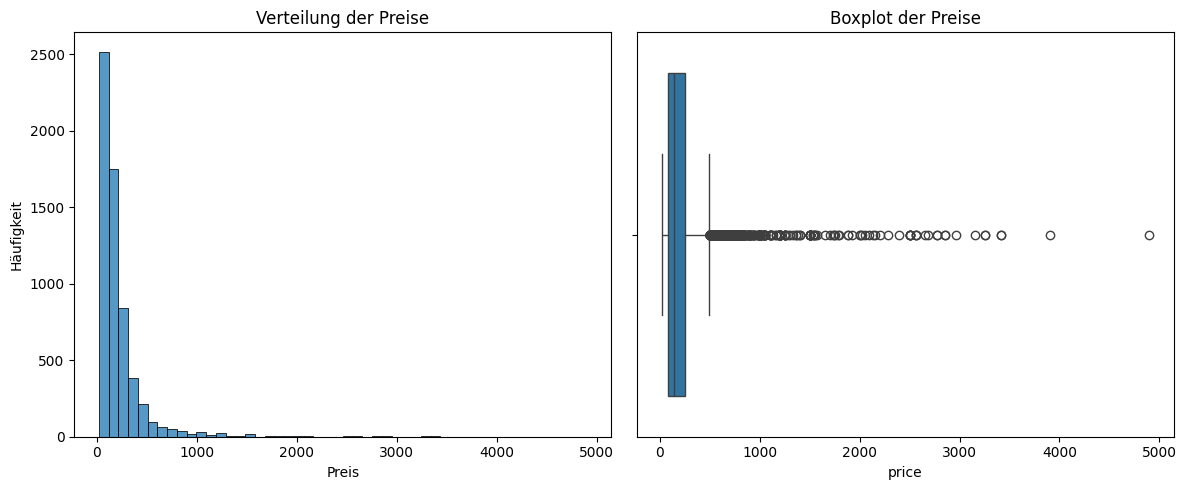

In [177]:
plt.figure(figsize=(12,5))

# Histogramm (links)
plt.subplot(1,2,1)
sns.histplot(airbnb["price"], bins=50)
plt.title("Verteilung der Preise")
plt.xlabel("Preis")
plt.ylabel("Häufigkeit")

# Boxplot (rechts)
plt.subplot(1,2,2)
sns.boxplot(x=airbnb["price"])
plt.title("Boxplot der Preise")

plt.tight_layout()
plt.show()

Die Verteilung der Airbnb-Preise ist deutlich rechtsschief. Das bedeutet, dass die meisten Unterkünfte in einem niedrigeren bis mittleren Preisbereich liegen, während nur wenige Listings sehr hohe Preise aufweisen. Diese wenigen sehr teuren Unterkünfte ziehen den Durchschnittspreis nach oben und erklären, warum der Mittelwert höher liegt als der Median.

Der Boxplot bestätigt diese Beobachtung. Er zeigt mehrere deutliche Ausreißer im oberen Preisbereich. Für die spätere Modellierung ist das wichtig, da solche extremen Werte die Vorhersage erschweren können. Insbesondere Fehlermetriken wie der RMSE reagieren empfindlich auf große Abweichungen bei sehr teuren Listings.

Aus diesem Grund sollte die Zielvariable im Modellierungsteil nicht unreflektiert verwendet werden. Eine Log-Transformation der Preise ist sinnvoll, weil sie die Rechtsschiefe reduziert und den Einfluss extremer Preise abschwächt. 

#### Log-Transformation:

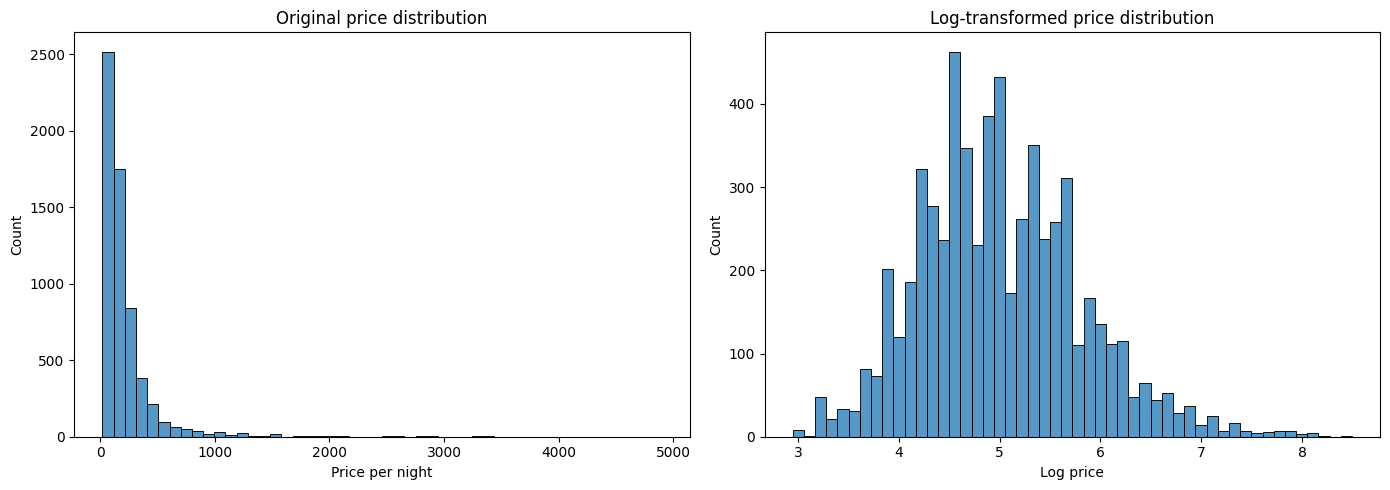

In [178]:
airbnb["log_price"] = np.log1p(airbnb["price"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(airbnb["price"], bins=50, ax=axes[0])
axes[0].set_title("Original price distribution")
axes[0].set_xlabel("Price per night")

sns.histplot(airbnb["log_price"], bins=50, ax=axes[1])
axes[1].set_title("Log-transformed price distribution")
axes[1].set_xlabel("Log price")

plt.tight_layout()
plt.show()

Die Log-Transformation reduziert die starke Rechtsschiefe der Preisverteilung deutlich. Dadurch werden extreme Preiswerte weniger dominant, während relative Preisunterschiede besser abgebildet werden. Für die spätere Modellierung ist dies sinnvoll, da viele Regressionsmodelle und Fehlermetriken empfindlich auf stark schiefe Zielvariablen und Ausreißer reagieren. Die finale Bewertung der Modelle sollte jedoch wieder auf der ursprünglichen Preisskala erfolgen, damit die Fehler in Dollar interpretierbar bleiben.

### 1.3.2 Verteilung der Unterkunftsgrößen

In diesem Schritt untersuchen wir die Verteilung von vier Variablen, die die Größe und Kapazität der Airbnb-Unterkünfte beschreiben: `accommodates`, `bedrooms`, `beds` und `bathrooms`.

Da es sich bei diesen Variablen um diskrete Zählvariablen handelt, verwenden wir Countplots statt Histogrammen. Ein Countplot zeigt, wie häufig jeder einzelne Wert im Datensatz vorkommt. Dadurch lässt sich zum Beispiel direkt erkennen, wie viele Unterkünfte ein Schlafzimmer, zwei Schlafzimmer oder mehrere Schlafzimmer haben.

Diese Variablen sind für die spätere Preisvorhersage relevant, da größere Unterkünfte tendenziell höhere Preise erwarten lassen. Größere Listings können mehr Gäste aufnehmen und verfügen häufig über mehr Wohnfläche oder Ausstattung. Gleichzeitig hilft die Analyse zu erkennen, welche Unterkunftsgrößen im Datensatz dominieren und ob es seltene, aber potenziell einflussreiche große Unterkünfte gibt.

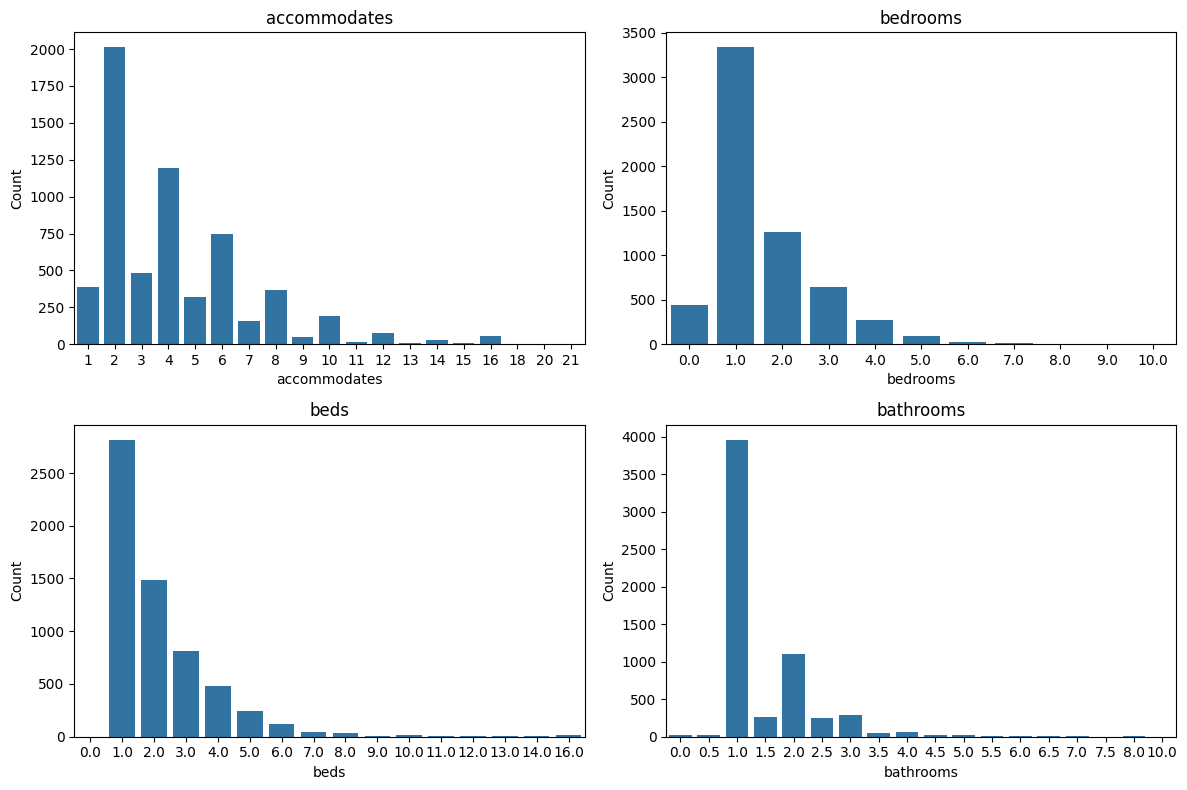

In [179]:
variables = ["accommodates", "bedrooms", "beds", "bathrooms"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, var in zip(axes.flatten(), variables):
    sns.countplot(data=airbnb, x=var, ax=ax)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Die Plots zeigen, dass die meisten Airbnb-Unterkünfte im Datensatz eher klein bis mittelgroß sind. Die meisten Listings können nur eine begrenzte Anzahl an Gästen aufnehmen und verfügen typischerweise über ein bis zwei Schlafzimmer, Betten und Badezimmer. Sehr große Unterkünfte mit vielen Schlafzimmern, Betten oder Badezimmern kommen deutlich seltener vor.

Damit wird deutlich, dass der Datensatz vor allem von kleineren Unterkünften geprägt ist. Gleichzeitig können die wenigen großen Unterkünfte trotzdem wichtig sein, da sie tendenziell höhere Preise aufweisen können und dadurch die spätere Preisvorhersage beeinflussen. Die Verteilungen sind daher rechtsschief: Viele Beobachtungen konzentrieren sich auf niedrige Werte, während nur wenige Beobachtungen sehr hohe Werte haben.

Auffällig ist außerdem, dass einzelne Beobachtungen Werte von 0 bei Variablen wie `bedrooms`, `beds` oder `bathrooms` aufweisen können. Bei `bedrooms` kann dies plausibel sein, da Studio-Apartments häufig kein separates Schlafzimmer besitzen. Bei `beds` und `bathrooms` sollten solche Werte jedoch vorsichtig interpretiert werden, da sie auch auf Sonderfälle, Kodierungsentscheidungen oder fehlende Angaben hindeuten könnten. Deshalb werden diese Werte an dieser Stelle nicht automatisch entfernt, sondern zunächst nur dokumentiert.

Für die Modellierung sind diese Variablen voraussichtlich nützliche Prädiktoren, da sie die physische Größe und Kapazität einer Unterkunft abbilden. Gleichzeitig sollte die Modellgüte später sorgfältig geprüft werden, insbesondere bei großen und ungewöhnlichen Listings, die im Datensatz nur selten vorkommen und daher für das Modell schwieriger zu lernen sein können.

### 1.3.3 Verteilung von Zimmer- und Unterkunftstypen

Neben der Größe einer Unterkunft können auch der Zimmer- und Unterkunftstyp den Preis beeinflussen. Ein gesamtes Apartment oder Haus bietet Gästen in der Regel mehr Privatsphäre und Unabhängigkeit als ein privates oder geteiltes Zimmer. Daher ist zu erwarten, dass sich die Preise zwischen den verschiedenen Kategorien unterscheiden.

Im Datensatz sind diese kategorialen Informationen bereits als Dummy-Variablen codiert. In diesem Abschnitt wird zunächst untersucht, wie häufig die einzelnen Kategorien vorkommen. Der anschließende Abschnitt betrachtet dann, wie sich die Preise zwischen den Kategorien unterscheiden.

,count,share
pg_House,2575,0.421440
rt_Private_room,1823,0.298363
pg_Condominium,556,0.090998
pg_Other,533,0.087234
pg_Townhouse,207,0.033879
rt_Shared_room,171,0.027987


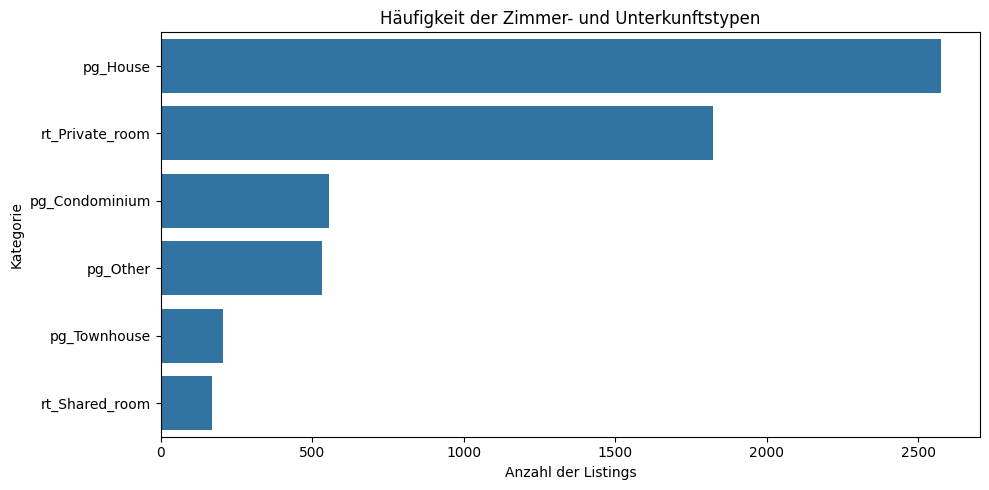

In [180]:
# Häufigkeit und Anteil der Ausprägung 1 berechnen
binary_summary = pd.DataFrame({
    "count": airbnb[binary_cols].sum(),
    "share": airbnb[binary_cols].mean()
}).sort_values("count", ascending=False)

display(binary_summary)

# Balkendiagramm der Dummy-Variablen erstellen
plt.figure(figsize=(10, 5))
sns.barplot(x=binary_summary["count"], y=binary_summary.index)

plt.title("Häufigkeit der Zimmer- und Unterkunftstypen")
plt.xlabel("Anzahl der Listings")
plt.ylabel("Kategorie")
plt.tight_layout()
plt.show()

Die Häufigkeiten und Anteile der Dummy-Variablen zeigen, welche Zimmer- und Unterkunftstypen im Datensatz besonders stark vertreten sind. Die absoluten Häufigkeiten geben an, wie viele Listings zu einer Kategorie gehören, während die Anteile zeigen, wie groß diese Kategorie relativ zum gesamten Datensatz ist. Häufig vorkommende Kategorien haben für die spätere Modellierung eine größere Datenbasis, während seltene Kategorien schwieriger zuverlässig zu modellieren sind. Besonders seltene Kategorien können dazu führen, dass das Modell deren Preise weniger stabil lernt.
Beispielsweise ist `pg_House` eine der am stärksten vertretenen Kategorien, während `rt_Shared_room` nur einen sehr kleinen Anteil der Listings ausmacht. Dadurch sind Aussagen über geteilte Zimmer tendenziell unsicherer als Aussagen über häufiger vorkommende Kategorien.

Beispielsweise ist `pg_House` eine der am stärksten vertretenen Kategorien, während `rt_Shared_room` nur einen sehr kleinen Anteil der Listings ausmacht. Dadurch sind Aussagen über geteilte Zimmer tendenziell unsicherer als Aussagen über häufiger vorkommende Kategorien.

Bei den Zimmertypen ist wichtig zu beachten, dass nicht jede Kategorie explizit als eigene Spalte dargestellt wird. Wenn die Dummy-Variablen `rt_Private_room` und `rt_Shared_room` beide den Wert 0 haben, handelt es sich um die ausgelassene Referenzkategorie. Diese entspricht hier einer gesamten Unterkunft, also `Entire home/apt`.

Diese Codierung ist für die Interpretation der späteren Modelle wichtig: Die Dummy-Variablen zeigen nicht den absoluten Effekt einer Kategorie, sondern den Unterschied im Vergleich zur ausgelassenen Referenzkategorie.

Bevor die Preisunterschiede zwischen den Kategorien visualisiert werden, werden aus den Dummy-Variablen lesbare Kategorienamen erstellt. Dadurch können die folgenden Diagramme verständlicher beschriftet werden.

Bei den Property-Groups entsteht ebenfalls eine Referenzkategorie, wenn keine der expliziten Property-Dummy-Variablen den Wert 1 annimmt. Diese Kategorie wird im Folgenden als `Other baseline` bezeichnet, sollte aber vorsichtig interpretiert werden, da sie nicht direkt als eigene Spalte im Datensatz vorliegt.

In [181]:
# Labels für Zimmertyp und Unterkunftsart erstellen

def room_type(row):
    if row["rt_Shared_room"] == 1:
        return "Shared room"
    elif row["rt_Private_room"] == 1:
        return "Private room"
    else:
        return "Entire home/apt"


def property_group(row):
    if row["pg_House"] == 1:
        return "House"
    elif row["pg_Condominium"] == 1:
        return "Condominium"
    elif row["pg_Townhouse"] == 1:
        return "Townhouse"
    elif row["pg_Other"] == 1:
        return "Other"
    else:
        return "Other baseline"


airbnb["room_type_label"] = airbnb.apply(room_type, axis=1)
airbnb["property_group_label"] = airbnb.apply(property_group, axis=1)

airbnb[["rt_Private_room", "rt_Shared_room", "room_type_label",
        "pg_Condominium", "pg_House", "pg_Other", "pg_Townhouse",
        "property_group_label"]].head()

,rt_Private_room,rt_Shared_room,room_type_label,pg_Condominium,pg_House,pg_Other,pg_Townhouse,property_group_label
0,0,0,Entire home/apt,0,1,0,0,House
1,0,0,Entire home/apt,1,0,0,0,Condominium
2,1,0,Private room,0,0,0,0,Other baseline
3,1,0,Private room,0,1,0,0,House
4,1,0,Private room,0,1,0,0,House


### 1.3.4 Zimmer- und Unterkunftstypen im Vergleich zum Preis

Nachdem die Häufigkeit der Zimmer- und Unterkunftstypen betrachtet wurde, wird nun untersucht, wie sich die Preise zwischen diesen Kategorien unterscheiden. Dafür werden Boxplots verwendet, da sie Median, Streuung und Ausreißer der Preise pro Kategorie übersichtlich darstellen.

Besonders relevant ist zunächst der Vergleich zwischen gesamten Unterkünften, privaten Zimmern und geteilten Zimmern. Diese Kategorien unterscheiden sich vor allem im Grad an Privatsphäre und Nutzungsfläche, was sich plausiblerweise im Preis widerspiegeln kann.

Zusätzlich wird betrachtet, ob auch verschiedene Unterkunftsarten, etwa Häuser, Condominiums oder Townhouses, unterschiedliche Preisniveaus aufweisen.

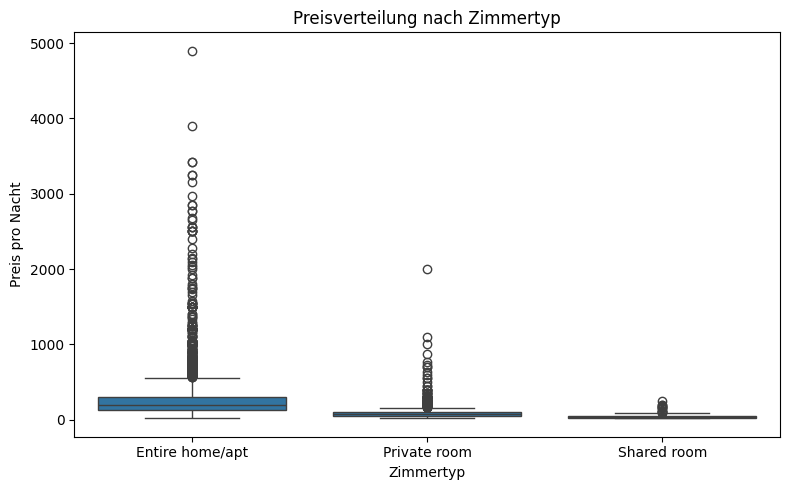

In [182]:
# Reihenfolge der Zimmertypen für den Boxplot festlegen
order = ["Entire home/apt", "Private room", "Shared room"]

# Boxplot zur Preisverteilung nach Zimmertyp erstellen
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=airbnb,
    x="room_type_label",
    y="price",
    order=order
)

plt.title("Preisverteilung nach Zimmertyp")
plt.xlabel("Zimmertyp")
plt.ylabel("Preis pro Nacht")
plt.tight_layout()
plt.show()

Der Boxplot zeigt deutliche Preisunterschiede zwischen den Zimmertypen. Gesamte Unterkünfte weisen im Vergleich zu privaten und geteilten Zimmern die höchsten Preise auf. Dies ist nachvollziehbar, da Gäste bei einer gesamten Unterkunft mehr Privatsphäre, Platz und Unabhängigkeit erhalten.

Private Zimmer liegen preislich niedriger als gesamte Unterkünfte, bieten aber in der Regel mehr Komfort und Privatsphäre als geteilte Zimmer. Geteilte Zimmer weisen das niedrigste Preisniveau auf. Dieses Muster entspricht der ökonomischen Erwartung, dass ein höheres Maß an Privatsphäre und Nutzfläche mit höheren Preisen verbunden ist.

Auffällig ist außerdem, dass insbesondere bei gesamten Unterkünften viele Ausreißer im oberen Preisbereich auftreten. Das deutet darauf hin, dass sehr teure Listings vor allem in dieser Kategorie vorkommen. Für die spätere Modellierung ist das relevant, weil diese Ausreißer die Vorhersage erschweren können.

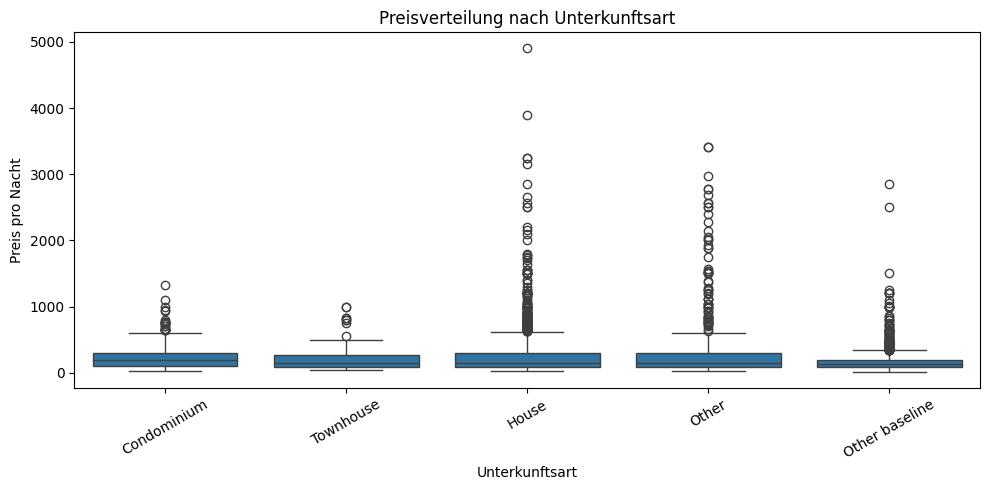

In [183]:
# Boxplot zur Preisverteilung nach Unterkunftsart erstellen
plt.figure(figsize=(10, 5))

property_order = (
    airbnb.groupby("property_group_label")["price"]
    .median()
    .sort_values(ascending=False)
    .index
)

sns.boxplot(
    data=airbnb,
    x="property_group_label",
    y="price",
    order=property_order
)

plt.title("Preisverteilung nach Unterkunftsart")
plt.xlabel("Unterkunftsart")
plt.ylabel("Preis pro Nacht")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Der zweite Boxplot zeigt die Preisverteilung nach Unterkunftsart. Auch hier unterscheiden sich die Kategorien im Preisniveau, allerdings sind die Unterschiede weniger eindeutig als beim Zimmertyp. Häuser, Condominiums und andere Unterkunftsarten weisen insgesamt ähnliche Preisbereiche auf, unterscheiden sich aber in der Streuung und in der Anzahl sehr teurer Ausreißer.

Auffällig ist, dass insbesondere bei `House` und `Other` viele Ausreißer im oberen Preisbereich auftreten. Das deutet darauf hin, dass innerhalb dieser Kategorien sowohl normale als auch sehr hochpreisige Unterkünfte vorkommen. Eine mögliche Erklärung ist, dass diese Kategorien sehr unterschiedliche Objekte enthalten können, zum Beispiel einfache Häuser, größere Ferienhäuser oder besonders hochwertige Unterkünfte.

Die Kategorie `Other baseline` sollte vorsichtig interpretiert werden, da sie keine direkt beobachtete ursprüngliche Kategorie ist, sondern die Referenzkategorie der Dummy-Codierung darstellt. Sie umfasst Listings, bei denen keine der expliziten Property-Dummy-Variablen den Wert 1 hat. Deshalb ist diese Kategorie weniger eindeutig interpretierbar als beispielsweise `House` oder `Condominium`.

Insgesamt zeigen die beiden Boxplots, dass sowohl der Zimmertyp als auch die Unterkunftsart relevante Informationen für die Preisvorhersage enthalten können. Der Zimmertyp scheint dabei besonders klare Preisunterschiede abzubilden, während die Unterkunftsart zusätzliche Unterschiede in Streuung und Ausreißern sichtbar macht.

### 1.3.5 Unterkunftsgröße im Vergleich zum Preis

Neben dem Zimmertyp wird nun untersucht, wie die maximale Gästeanzahl mit dem Preis zusammenhängt. Die Variable `accommodates` beschreibt, wie viele Personen in einer Unterkunft übernachten können, und dient daher als wichtiger Indikator für die Kapazität eines Listings.

Da größere Unterkünfte mehr Gäste aufnehmen können, ist ein positiver Zusammenhang zwischen `accommodates` und dem Preis zu erwarten. Gleichzeitig ist zu beachten, dass die Preisvariable stark rechtsschief verteilt ist und einzelne sehr teure Listings den sichtbaren Zusammenhang beeinflussen können.

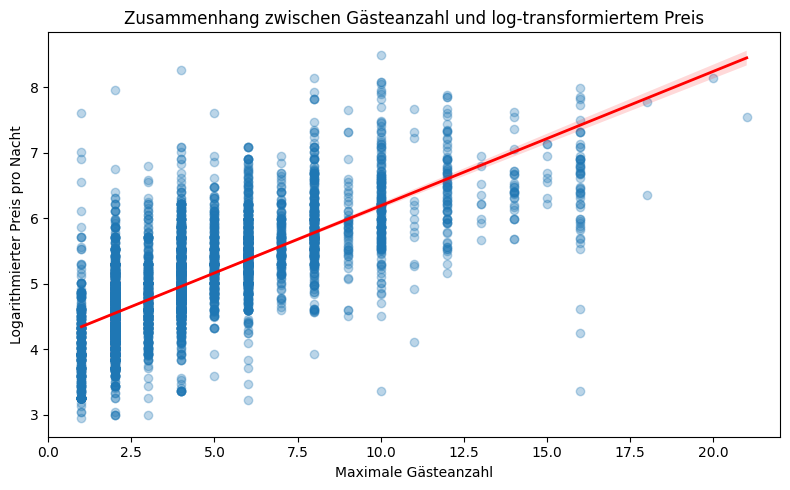

In [184]:
# Zusammenhang zwischen maximaler Gästeanzahl und log-transformiertem Preis visualisieren
plt.figure(figsize=(8, 5))

sns.regplot(
    data=airbnb,
    x="accommodates",
    y="log_price",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red", "linewidth": 2}
)

plt.title("Zusammenhang zwischen Gästeanzahl und log-transformiertem Preis")
plt.xlabel("Maximale Gästeanzahl")
plt.ylabel("Logarithmierter Preis pro Nacht")
plt.tight_layout()
plt.show()

Der Scatterplot zeigt auch auf der log-transformierten Preisskala einen grundsätzlich positiven Zusammenhang zwischen der maximalen Gästeanzahl und dem Preis. Unterkünfte, die mehr Personen aufnehmen können, sind tendenziell teurer. Dies ist plausibel, da größere Unterkünfte mehr Platz bieten und von größeren Reisegruppen genutzt werden können.

Der Zusammenhang ist jedoch nicht perfekt linear. Bei gleicher Gästeanzahl gibt es weiterhin deutliche Preisunterschiede. Das zeigt, dass die Kapazität einer Unterkunft zwar ein wichtiger Faktor ist, den Preis aber nicht allein erklären kann.

Die Verwendung des log-transformierten Preises reduziert den Einfluss sehr teurer Ausreißer und macht den allgemeinen Zusammenhang besser sichtbar. Gleichzeitig bleiben Unterschiede innerhalb gleicher Kapazitätsgruppen bestehen. Dies deutet darauf hin, dass weitere Faktoren wie Lage, Ausstattung, Qualität, Unterkunftstyp und Umgebung ebenfalls eine wichtige Rolle spielen. Für die spätere Modellierung bedeutet dies, dass mehrere Merkmale gemeinsam betrachtet werden müssen.

### 1.3.6 Korrelationsanalyse numerischer Merkmale

Die Korrelationsmatrix dient dazu, erste lineare Zusammenhänge zwischen den numerischen Variablen und der Preisvariable zu untersuchen. Besonders relevant ist dabei die Frage, welche Merkmale positiv oder negativ mit dem Airbnb-Preis zusammenhängen.

Da die ursprüngliche Preisvariable stark rechtsschief verteilt ist, wird für diese Analyse zusätzlich der log-transformierte Preis verwendet. Dadurch wird der Einfluss einzelner sehr teurer Listings reduziert und die Analyse ist besser an die spätere Modellierung angepasst.

Eine positive Korrelation bedeutet, dass höhere Werte einer Variable tendenziell mit höheren Preisen einhergehen. Eine negative Korrelation bedeutet dagegen, dass höhere Werte einer Variable eher mit niedrigeren Preisen verbunden sind.

Wichtig ist jedoch, dass Korrelationen nur einfache paarweise lineare Zusammenhänge abbilden. Sie zeigen keine kausalen Effekte und berücksichtigen keine komplexen Wechselwirkungen zwischen mehreren Variablen. Für die spätere Modellierung sind sie daher als erste Orientierung hilfreich, ersetzen aber kein Machine-Learning-Modell.

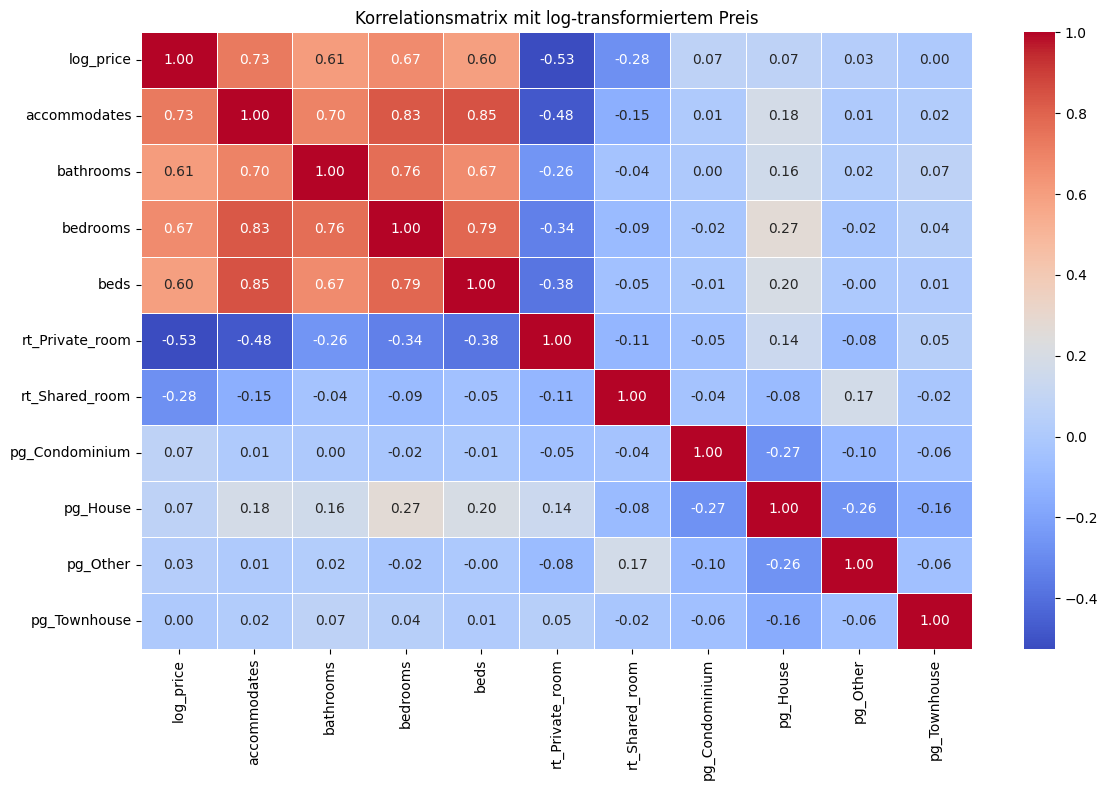

In [185]:
airbnb["log_price"] = np.log1p(airbnb["price"])

# Auswahl der Variablen, die für die Korrelationsanalyse verwendet werden
feature_cols_basic = [
    "accommodates",      # Anzahl der Personen, die in der Unterkunft übernachten können
    "bathrooms",         # Anzahl der Badezimmer
    "bedrooms",          # Anzahl der Schlafzimmer
    "beds",              # Anzahl der Betten

    # Binäre Variablen: 1 bedeutet, dass die Eigenschaft zutrifft, 0 bedeutet, dass sie nicht zutrifft
    "rt_Private_room",   # Zimmertyp: privates Zimmer
    "rt_Shared_room",    # Zimmertyp: geteiltes Zimmer
    "pg_Condominium",    # Unterkunftsart: Eigentumswohnung
    "pg_House",          # Unterkunftsart: Haus
    "pg_Other",          # Unterkunftsart: sonstige Unterkunft
    "pg_Townhouse",      # Unterkunftsart: Stadthaus
]

# Korrelationsmatrix für log-transformierten Preis und ausgewählte erklärende Variablen berechnen
corr = airbnb[["log_price"] + feature_cols_basic].corr()

# Heatmap der Korrelationsmatrix erstellen
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Korrelationsmatrix mit log-transformiertem Preis")
plt.tight_layout()
plt.show()

Die Korrelationsmatrix bestätigt mehrere Muster, die bereits in den vorherigen Visualisierungen sichtbar waren. Die Variablen zur Größe der Unterkunft, insbesondere `accommodates`, `bedrooms`, `beds` und `bathrooms`, weisen positive Korrelationen mit dem log-transformierten Preis auf. Das bedeutet, dass größere Unterkünfte tendenziell höhere Preise erzielen.

Auch die Dummy-Variablen für die Zimmer- und Unterkunftstypen zeigen plausible Zusammenhänge. Private und geteilte Zimmer stehen eher mit niedrigeren Preisen in Verbindung, da sie im Vergleich zu gesamten Unterkünften weniger Privatsphäre und Nutzfläche bieten. Bestimmte Unterkunftsarten wie Häuser können dagegen mit höheren Preisen verbunden sein, da sie häufig mehr Platz bieten.

Zusätzlich ist erkennbar, dass die Größenvariablen auch untereinander zusammenhängen. Dies ist plausibel, da Unterkünfte mit mehr Gästen häufig auch mehr Schlafzimmer, Betten oder Badezimmer besitzen. Für lineare Modelle könnte eine solche Multikollinearität die Interpretation einzelner Koeffizienten erschweren. Für baumbasierte Modelle wie Random Forest oder XGBoost ist dies weniger problematisch, sollte aber bei der späteren Modellinterpretation berücksichtigt werden.

Die Ergebnisse sollten insgesamt vorsichtig interpretiert werden. Die Korrelationsmatrix zeigt nur lineare Zusammenhänge zwischen jeweils zwei Variablen. Sie berücksichtigt nicht, dass sich mehrere Merkmale gegenseitig beeinflussen können. Beispielsweise kann der Zusammenhang zwischen Schlafzimmeranzahl und Preis je nach Lage oder Unterkunftstyp unterschiedlich ausfallen.

Trotz dieser Einschränkung liefert die Korrelationsanalyse eine sinnvolle erste Orientierung. Sie zeigt, dass die ausgewählten Variablen relevante Informationen für die spätere Preisvorhersage enthalten.

## 1.4 Räumliche Analyse

Da der Datensatz räumliche Informationen enthält, wird abschließend untersucht, wie die Airbnb-Listings innerhalb von San Diego verteilt sind. Die räumliche Lage kann für die Preisbildung eine wichtige Rolle spielen, da Gäste bestimmte Standorte aufgrund von Nähe zu Küste, Innenstadt, Sehenswürdigkeiten, Restaurants oder anderen Freizeitangeboten bevorzugen könnten.

In diesem Schritt werden die Listings daher auf einer Karte dargestellt. Zusätzlich wird der Preis farblich visualisiert, um erste räumliche Muster im Preisniveau zu erkennen. Da einzelne sehr teure Listings die Farbdarstellung stark verzerren können, wird die Farbskala über Quantile begrenzt. Die Karte dient damit der explorativen Mustererkennung und nicht der exakten Bewertung einzelner Listings.

Diese Analyse ist die Grundlage für den nächsten Teil, in dem Points of Interest aus OpenStreetMap als zusätzliche räumliche Informationen eingebunden werden.

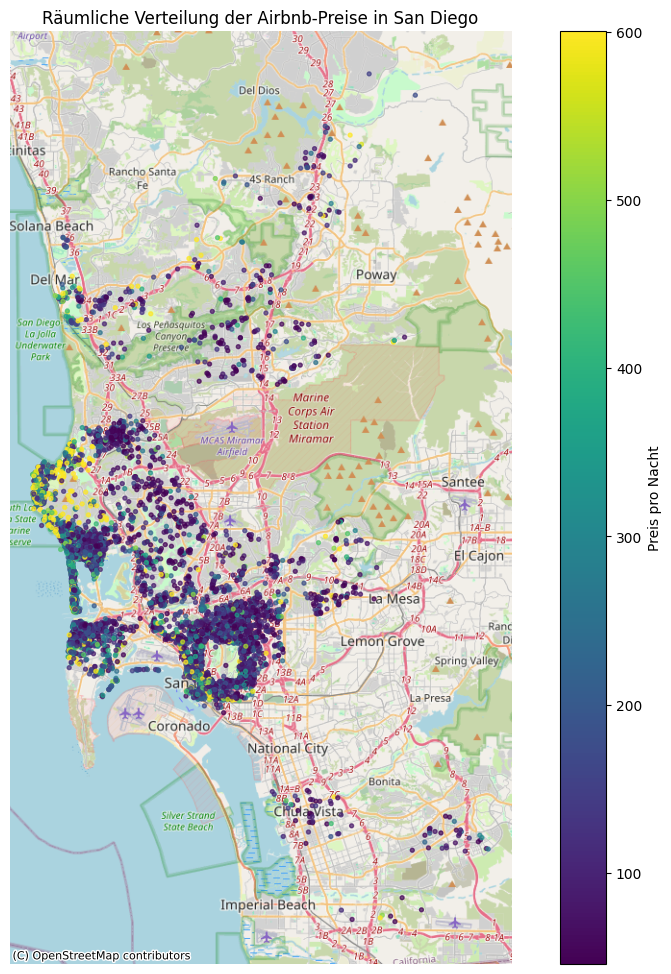

In [186]:
# GeoDataFrame in Web-Mercator-Projektion umwandeln,
# damit die Daten mit der Basemap von contextily kompatibel sind
airbnb_3857 = airbnb.to_crs(epsg=3857)

# Farbskala über Quantile begrenzen,
# damit einzelne extreme Preise die Darstellung nicht dominieren
v_min = airbnb["price"].quantile(0.05)
v_max = airbnb["price"].quantile(0.95)

# Karte der Airbnb-Listings erstellen
fig, ax = plt.subplots(figsize=(10, 10))

airbnb_3857.plot(
    ax=ax,
    column="price",
    cmap="viridis",
    markersize=8,
    alpha=0.7,
    legend=True,
    vmin=v_min,
    vmax=v_max,
    legend_kwds={"label": "Preis pro Nacht"}
)

# Basemap hinzufügen
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

plt.title("Räumliche Verteilung der Airbnb-Preise in San Diego")
plt.axis("off")
plt.tight_layout()
plt.show()

Die Karte zeigt, dass die Airbnb-Listings nicht gleichmäßig über San Diego verteilt sind. Stattdessen konzentrieren sich viele Unterkünfte in bestimmten Bereichen, insbesondere in zentraleren und touristisch attraktiven Lagen. Dies deutet darauf hin, dass die räumliche Lage für das Airbnb-Angebot eine wichtige Rolle spielt.

Auch beim Preisniveau sind räumliche Unterschiede erkennbar. Höherpreisige Listings scheinen häufiger in attraktiven oder gut erreichbaren Lagen aufzutreten, während niedrigere Preise eher in anderen Bereichen zu finden sind. Diese Beobachtung ist plausibel, da Gäste häufig bereit sind, für eine gute Lage, Nähe zu Sehenswürdigkeiten, Küste, Gastronomie oder Freizeitangeboten mehr zu bezahlen.

Für die Farbdarstellung wurde die Skala über das 5%- und 95%-Quantil begrenzt. Dadurch dominieren einzelne extreme Ausreißer nicht die gesamte Farbskala, und räumliche Unterschiede im mittleren Preisbereich werden besser sichtbar. Die Karte sollte daher als explorative Visualisierung interpretiert werden und nicht als exakte Darstellung jedes einzelnen Preiswertes.

Die Karte allein beweist jedoch keinen kausalen Zusammenhang zwischen Lage und Preis. Sie zeigt zunächst nur ein räumliches Muster. Trotzdem liefert sie einen wichtigen Hinweis darauf, dass räumliche Informationen für die spätere Preisvorhersage relevant sein könnten.

Diese Beobachtung motiviert den nächsten Teil der Analyse: In Teil 2 werden zusätzliche räumliche Merkmale aus OpenStreetMap integriert. Insbesondere wird untersucht, ob die Dichte von Points of Interest wie Restaurants, Cafés und Bars zur Erklärung der Airbnb-Preise beitragen kann.

### Zwischenfazit zu Part 1

Die explorative Datenanalyse zeigt mehrere zentrale Muster. Erstens ist die Preisvariable deutlich rechtsschief verteilt und enthält einige sehr teure Ausreißer. Deshalb ist eine log-transformierte Preisvariable für spätere Analysen und Modelle sinnvoll, da sie den Einfluss extremer Werte reduziert.

Zweitens zeigen die Größenvariablen wie `accommodates`, `bedrooms`, `beds` und `bathrooms` plausible positive Zusammenhänge mit dem Preis. Größere Unterkünfte sind tendenziell teurer, allerdings erklären diese Variablen den Preis nicht vollständig.

Drittens unterscheiden sich die Preise deutlich zwischen verschiedenen Zimmertypen und Unterkunftsarten. Insbesondere gesamte Unterkünfte weisen höhere Preise und mehr Ausreißer im oberen Preisbereich auf als private oder geteilte Zimmer.

Viertens zeigt die räumliche Karte, dass Airbnb-Angebote und Preisniveaus innerhalb von San Diego nicht gleichmäßig verteilt sind. Diese Beobachtung motiviert die Erweiterung des Datensatzes um räumliche Merkmale in Part 2. Dort wird untersucht, ob die Nähe beziehungsweise Dichte von Points of Interest zusätzliche Informationen für die Preisvorhersage liefert.

# PART 2: Feature Engineering
In diesem Teil werden zusätzliche räumliche Merkmale erstellt, die über die ursprünglichen Airbnb-Listing-Informationen hinausgehen. Die zentrale Annahme ist, dass nicht nur Eigenschaften der Unterkunft selbst, sondern auch die räumliche Umgebung einen Einfluss auf den Preis haben können.

Besonders relevant sind Points of Interest (POIs), die für Gäste während eines Aufenthalts attraktiv oder praktisch sein können. Dazu zählen in dieser Analyse Restaurants, Cafés und Bars. Eine hohe Dichte solcher Angebote kann auf zentrale, lebendige oder touristisch attraktive Lagen hinweisen.

Zur Quantifizierung dieser räumlichen Umgebung werden zwei unterschiedliche Ansätze verwendet. Erstens wird eine Kernel Density Estimation (KDE) berechnet, die eine kontinuierliche Dichte von POIs in der Umgebung eines Airbnb-Listings beschreibt. Zweitens werden Buffer-Features erstellt, bei denen gezählt wird, wie viele POIs innerhalb eines festen Radius um ein Listing liegen. Dadurch können später beide Feature-Typen miteinander verglichen werden.

In [187]:
import osmnx as ox
from scipy.stats import gaussian_kde
from sklearn.preprocessing import MinMaxScaler

## 2.1 Motivation und Auswahl der POI-Daten

Wir wählen drei amenity Kategorien, die für die Attraktivität und Wahl von Airbnbs besonders relevant sind:

- `restaurant`  
- `cafe` 
- `bar`  

Diese Kategorien wurden gewählt, weil gastronomische Angebote für touristische Aufenthalte besonders relevant sein können. Restaurants, Cafés und Bars erhöhen die Attraktivität eines Standorts, da sie Gästen leicht erreichbare Versorgungs- und Freizeitmöglichkeiten bieten. Eine hohe Konzentration solcher Angebote kann daher auf zentrale, lebendige oder touristisch interessante Lagen hinweisen.

Die Auswahl ist bewusst auf drei Kategorien begrenzt, damit die Analyse interpretierbar bleibt. Weitere POI-Kategorien wie Strände, Parks, ÖPNV-Haltestellen oder Sehenswürdigkeiten könnten in einer erweiterten Analyse zusätzlich berücksichtigt werden.

In [188]:
# Auswahl der POI-Kategorien
amenity_types = ["restaurant", "cafe", "bar"]


## 2.2 Download und räumliche Begrenzung der POI-Daten

Zunächst wird die Stadtgrenze von San Diego aus OpenStreetMap geladen. Dieses Stadtpolygon dient als räumliche Maske für die weitere Analyse. Dadurch kann sichergestellt werden, dass nur POIs innerhalb des Untersuchungsgebiets berücksichtigt werden.

Dieser Schritt ist wichtig, weil OpenStreetMap-Abfragen über einen Radius auch Objekte außerhalb der offiziellen Stadtgrenzen enthalten können. Ohne eine räumliche Begrenzung könnten daher POIs aus Nachbargebieten fälschlicherweise in die spätere Feature-Berechnung einfließen.

In [189]:
#geodaten von San Diego holen
gdf_SD = ox.geocode_to_gdf("San Diego, California, USA")

print(gdf_SD.crs)

epsg:4326


Die Geodaten wurden über OpenStreetmap standardmäßig im Koordinatenreferenzsystem  EPSG: 4326 geladen. Die Darstellung gibt Längen und Breitengrade in Grad an. 

Für räumliche Analysen wie Distanzen, Flächen, Buffer oder Kernel Density Estimation ist diese Darstellung jedoch ungeeignet, da Grad keine konstante metrische Entfernung darstellen. Deshalb erfolgt eine Transformation in ein projiziertes Koordinatensystem. 

Wir verwenden EPSG: 32611, da es für die Region San Diego lokal verzerrungsarm ist und Meter als Einheit bereitstellt. 

In [190]:
gdf_SD_projected = gdf_SD.to_crs(epsg=32611) #geometry spalte gibt grenzen an 
gdf_SD_projected.head()

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((470964.838 3619500.859, 471386...",-117.309816,32.534798,-116.905742,33.114194,316257697,relation,253832,32.71742,-117.162772,boundary,administrative,16,0.731978,city,San Diego,"San Diego, San Diego County, California, Unite..."


In [191]:
#crs anschauen 
gdf_SD_projected.crs

<Projected CRS: EPSG:32611>
Name: WGS 84 / UTM zone 11N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 120°W and 114°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Alberta; British Columbia (BC); Northwest Territories (NWT); Nunavut. Mexico. United States (USA).
- bounds: (-120.0, 0.0, -114.0, 84.0)
Coordinate Operation:
- name: UTM zone 11N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [192]:
#karte zum überprüfen 
gdf_SD_projected.explore()

Zunächst laden wir POIs innerhalb eines 40 km Radius um San Diego. Der Radius ist bewusst großzügig gewählt, damit auch POIs am Rand des Stadtgebiets vollständig erfasst werden. 

Da eine solche Radiusabfrage jedoch auch POIs außerhalb der offiziellen Stadtgrenzen enthalten kann, verwenden wir anschließend das Stadtpolygon von San Diego, um mit der clip Operation alle außerhalb liegenden Geometrien zu entfernen. Dadurch gehen nur POIs innerhalb des Untersuchungsgebiets in die weitere Analyse ein.

In [193]:
# Download the POI data 
pois = ox.features_from_address(
    "San Diego, California, USA",
    tags={"amenity": amenity_types},
    dist=40000
)

print(f"Downloaded {len(pois)} POI features")


Downloaded 3597 POI features


Vor dem Clipping werden beide Datensätze auf dasselbe Koordinatenreferenzsystem 
(CRS) transformiert. Geometrische Operationen wie `.clip()` liefern nur dann korrekte Ergebnisse, wenn alle beteiligten Datensätze im selben CRS vorliegen.

In [194]:
#pois auf selbes crs bringen
pois = pois.to_crs(gdf_SD_projected.crs)
pois.crs

<Projected CRS: EPSG:32611>
Name: WGS 84 / UTM zone 11N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 120°W and 114°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Alberta; British Columbia (BC); Northwest Territories (NWT); Nunavut. Mexico. United States (USA).
- bounds: (-120.0, 0.0, -114.0, 84.0)
Coordinate Operation:
- name: UTM zone 11N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [195]:
pois.head()

geometry  addr:city addr:housenumber  \
element id                                                                      
node    273607070  POINT (478969.902 3636051.156)  San Diego             7748   
        273607369  POINT (478974.338 3636012.191)  San Diego             7728   
        274193511  POINT (482797.584 3631501.426)  San Diego             4310   
        274358074  POINT (478975.575 3636096.674)        NaN              NaN   
        274363369  POINT (483728.162 3632858.301)        NaN              NaN   

                  addr:postcode addr:state     addr:street     amenity  \
element id                                                               
node    273607070         92122         CA    Regents Road  restaurant   
        273607369         92122         CA  Regents Street  restaurant   
        274193511         92117         CA  Genesee Avenue  restaurant   
        274358074           NaN        NaN             NaN        cafe   
        274363369           NaN        NaN             NaN  restaurant   

                                                     name changing_table  \
element id                                                                 
node    273607070  Leucadia Pizzeria & Italian Restaurant            NaN   
        273607369                                  Egglet            NaN   
        274193511                             Thai Time 3            NaN   
        274358074                         Tapioca Express            NaN   
        274363369                        Sipz Fusion Cafe            NaN   

                     cuisine  ... building:part payment:notes cafe fast_food  \
element id                    ...                                              
node    273607070    italian  ...           NaN           NaN  NaN       NaN   
        273607369  breakfast  ...           NaN           NaN  NaN       NaN   
        274193511       thai  ...           NaN           NaN  NaN       NaN   
        274358074        tea  ...           NaN           NaN  NaN       NaN   
        274363369        NaN  ...           NaN           NaN  NaN       NaN   

                  construction access type building:material roof:colour  \
element id                                                                 
node    273607070          NaN    NaN  NaN               NaN         NaN   
        273607369          NaN    NaN  NaN               NaN         NaN   
        274193511          NaN    NaN  NaN               NaN         NaN   
        274358074          NaN    NaN  NaN               NaN         NaN   
        274363369          NaN    NaN  NaN               NaN         NaN   

                  year_of_construction  
element id                              
node    273607070                  NaN  
        273607369                  NaN  
        274193511                  NaN  
        274358074                  NaN  
        274363369                  NaN  

[5 rows x 259 columns]

In [196]:
#pois eingrenzen mit clip funktion 
pois_sd = pois.clip(gdf_SD_projected)
pois_sd.head()

geometry  \
element id                                                               
way     31819108     POLYGON ((492032.455 3604245.134, 492032.509 3...   
node    12397642459                     POINT (492025.219 3604387.508)   
        365318026                       POINT (492070.342 3605019.965)   
way     218923462    POLYGON ((490836.592 3605120.289, 490836.1 360...   
        31800568     POLYGON ((491022.114 3605114.467, 491015.084 3...   

                     addr:city addr:housenumber addr:postcode addr:state  \
element id                                                                 
way     31819108           NaN              NaN           NaN        NaN   
node    12397642459  San Diego             2222         92154         CA   
        365318026          NaN              NaN           NaN        NaN   
way     218923462          NaN             1669           NaN        NaN   
        31800568           NaN             1759           NaN        NaN   

                         addr:street     amenity                    name  \
element id                                                                 
way     31819108                 NaN  restaurant  Ed Fernandez Birrieria   
node    12397642459  Coronado Avenue  restaurant                 Denny's   
        365318026                NaN         bar          La Vuelta Club   
way     218923462                NaN  restaurant            Jalisco Cafe   
        31800568                 NaN  restaurant   El Chile Mexican Food   

                    changing_table   cuisine  ... building:part payment:notes  \
element id                                    ...                               
way     31819108               NaN   mexican  ...           NaN           NaN   
node    12397642459            NaN  american  ...           NaN           NaN   
        365318026              NaN       NaN  ...           NaN           NaN   
way     218923462              NaN   mexican  ...           NaN           NaN   
        31800568               NaN   mexican  ...           NaN           NaN   

                    cafe fast_food construction access type building:material  \
element id                                                                      
way     31819108     NaN       NaN          NaN    NaN  NaN               NaN   
node    12397642459  NaN       NaN          NaN    NaN  NaN               NaN   
        365318026    NaN       NaN          NaN    NaN  NaN               NaN   
way     218923462    NaN       NaN          NaN    NaN  NaN               NaN   
        31800568     NaN       NaN          NaN    NaN  NaN               NaN   

                    roof:colour year_of_construction  
element id                                            
way     31819108            NaN                  NaN  
node    12397642459         NaN                  NaN  
        365318026           NaN                  NaN  
way     218923462           NaN                  NaN  
        31800568            NaN                  NaN  

[5 rows x 259 columns]

In [197]:
print("Vor Clipping:", len(pois))
print("Nach Clipping:", len(pois_sd))

Vor Clipping: 3597
Nach Clipping: 2189


Nach dem Clipping umfasst unser POI-Datensatz noch 2.189 Einträge. Dies sind ausschließlich 
die POIs, die innerhalb der Stadtgrenzen San Diegos liegen. Alle weiteren Analysen basieren damit auf lokal relevantem Datenmaterial.

In [198]:
# Häufigkeit und Anteil der POI-Kategorien berechnen
poi_summary = (
    pois_sd["amenity"]
    .value_counts()
    .rename_axis("amenity")
    .reset_index(name="count")
)

poi_summary["share"] = poi_summary["count"] / poi_summary["count"].sum()

poi_summary

,amenity,count,share
0,restaurant,1418,0.647784
1,cafe,487,0.222476
2,bar,284,0.129740


Die Tabelle zeigt, wie häufig die ausgewählten POI-Kategorien im Untersuchungsgebiet vorkommen. Diese Information ist wichtig, weil die Stabilität räumlicher Features auch von der Anzahl der verfügbaren POIs abhängt.

Kategorien mit vielen Beobachtungen liefern in der Regel stabilere räumliche Muster. Kategorien mit wenigen Beobachtungen können stärker von einzelnen Standorten beeinflusst sein und sollten daher bei der späteren Interpretation vorsichtiger betrachtet werden.

In [199]:
# Geometrietypen der POIs prüfen
pois_sd.geom_type.value_counts()

Point      1903
Polygon     286
Name: count, dtype: int64

OpenStreetMap-POIs können unterschiedliche Geometrietypen besitzen. Einige Einträge liegen direkt als Punkte vor, andere als Polygone oder Multipolygone, zum Beispiel wenn ein Restaurant als Gebäudeumriss erfasst wurde.

Für KDE- und Buffer-Berechnungen werden POIs als Punktpositionen benötigt. Deshalb werden flächenhafte Geometrien im nächsten Schritt in repräsentative Punktgeometrien umgewandelt.

In [200]:
# POIs für KDE und Buffer-Features als Punktgeometrien vorbereiten
pois_points = pois_sd.copy()

# Leere oder fehlende Geometrien entfernen
pois_points = pois_points[
    pois_points.geometry.notna() & ~pois_points.geometry.is_empty
].copy()

# Alle Geometrien in repräsentative Punkte umwandeln
pois_points["geometry"] = pois_points.geometry.representative_point()

pois_points.geom_type.value_counts()

Point    2189
Name: count, dtype: int64

## 2.3 Räumliche Analyse der POIs

Die nachfolgende Karte zeigt die räumliche Verteilung der drei POI-Kategorien 
innerhalb San Diegos. Restaurants, Cafés und Bars werden dabei farblich unterschieden, 
um räumliche Muster je Kategorie erkennbar zu machen.

Diese Visualisierung dient als erste Plausibilitätsprüfung, bevor die POIs in quantitative Features umgewandelt werden.

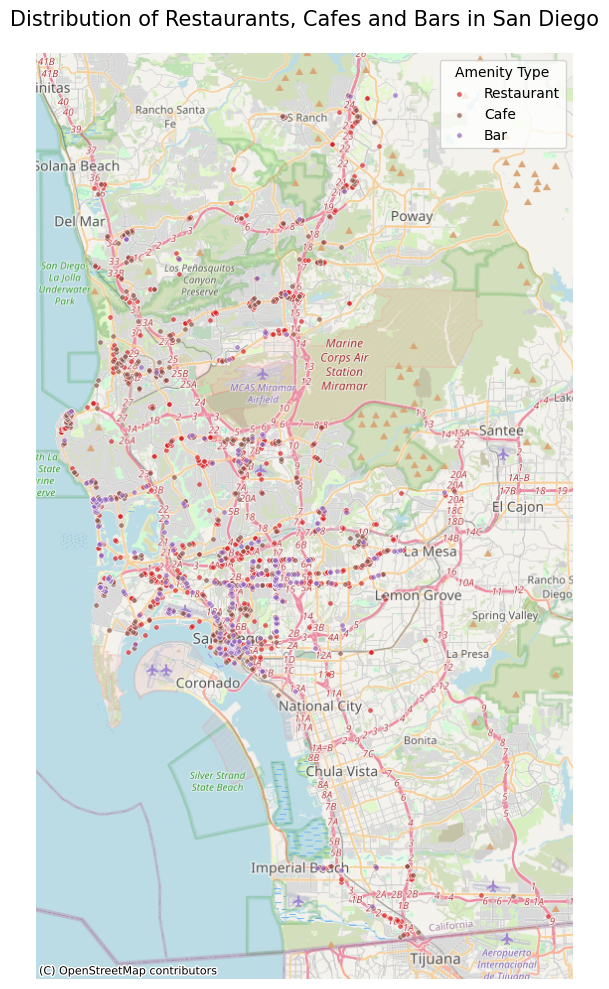

In [201]:
#um zu plotten temporär in Mercator (3857) transformieren
pois_3857 = pois_points.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 10))

amenity_colors = {
    "restaurant": "tab:red", 
    "cafe": "tab:brown", 
    "bar": "tab:purple"
}

for amenity, color in amenity_colors.items():
    subset = pois_3857[pois_3857["amenity"] == amenity]
    
    subset.plot(
        ax=ax, 
        color=color, 
        markersize=15,    
        alpha=0.7, 
        label=amenity.capitalize(),
        edgecolor="white", 
        linewidth=0.5
    )

cx.add_basemap(
    ax, 
    source=cx.providers.OpenStreetMap.Mapnik, 
    alpha=0.8
)


ax.legend(title="Amenity Type", fontsize=10, loc='upper right')
ax.set_title("Distribution of Restaurants, Cafes and Bars in San Diego", fontsize=15, pad=20)
ax.set_axis_off()

plt.tight_layout()
plt.show()

Die Karte zeigt, dass die POIs nicht gleichmäßig über San Diego verteilt sind. Stattdessen treten sie vor allem in bestimmten Bereichen konzentriert auf, insbesondere in urbanen, zentralen oder touristisch attraktiven Lagen.

Diese räumliche Konzentration ist für die spätere Modellierung relevant, weil sie darauf hinweist, dass gastronomische Infrastruktur ein Standortmerkmal darstellt. Airbnb-Listings in solchen Gebieten könnten für Gäste attraktiver sein, da Restaurants, Cafés und Bars leichter erreichbar sind.

Die Karte dient jedoch zunächst nur der explorativen Analyse. Sie zeigt räumliche Muster, beweist aber noch nicht, dass POI-Dichte tatsächlich höhere Airbnb-Preise verursacht. Ob diese Informationen die Preisvorhersage verbessern, wird später im Modellvergleich geprüft.

### Vergleich der geographischen Verteilung der Airbnbs und POIs:

Im nächsten Schritt vergleichen wir die räumliche Verteilung der AirBnBs 
mit jener der POIs. Dies gibt uns ein erstes intuitives Verständnis dafür, ob eine 
räumliche Beziehung zwischen den beiden Datensätzen erkennbar ist. Wir untersuchen ob AirBnBs 
tatsächlich gehäuft in der Nähe von Restaurants, Cafés und Bars auftreten. 

Ist dies der Fall, unterstützt das unsere Annahme, dass POI-Dichte ein sinnvolles Feature zur Vorhersage von AirBnB-Preisen darstellt.

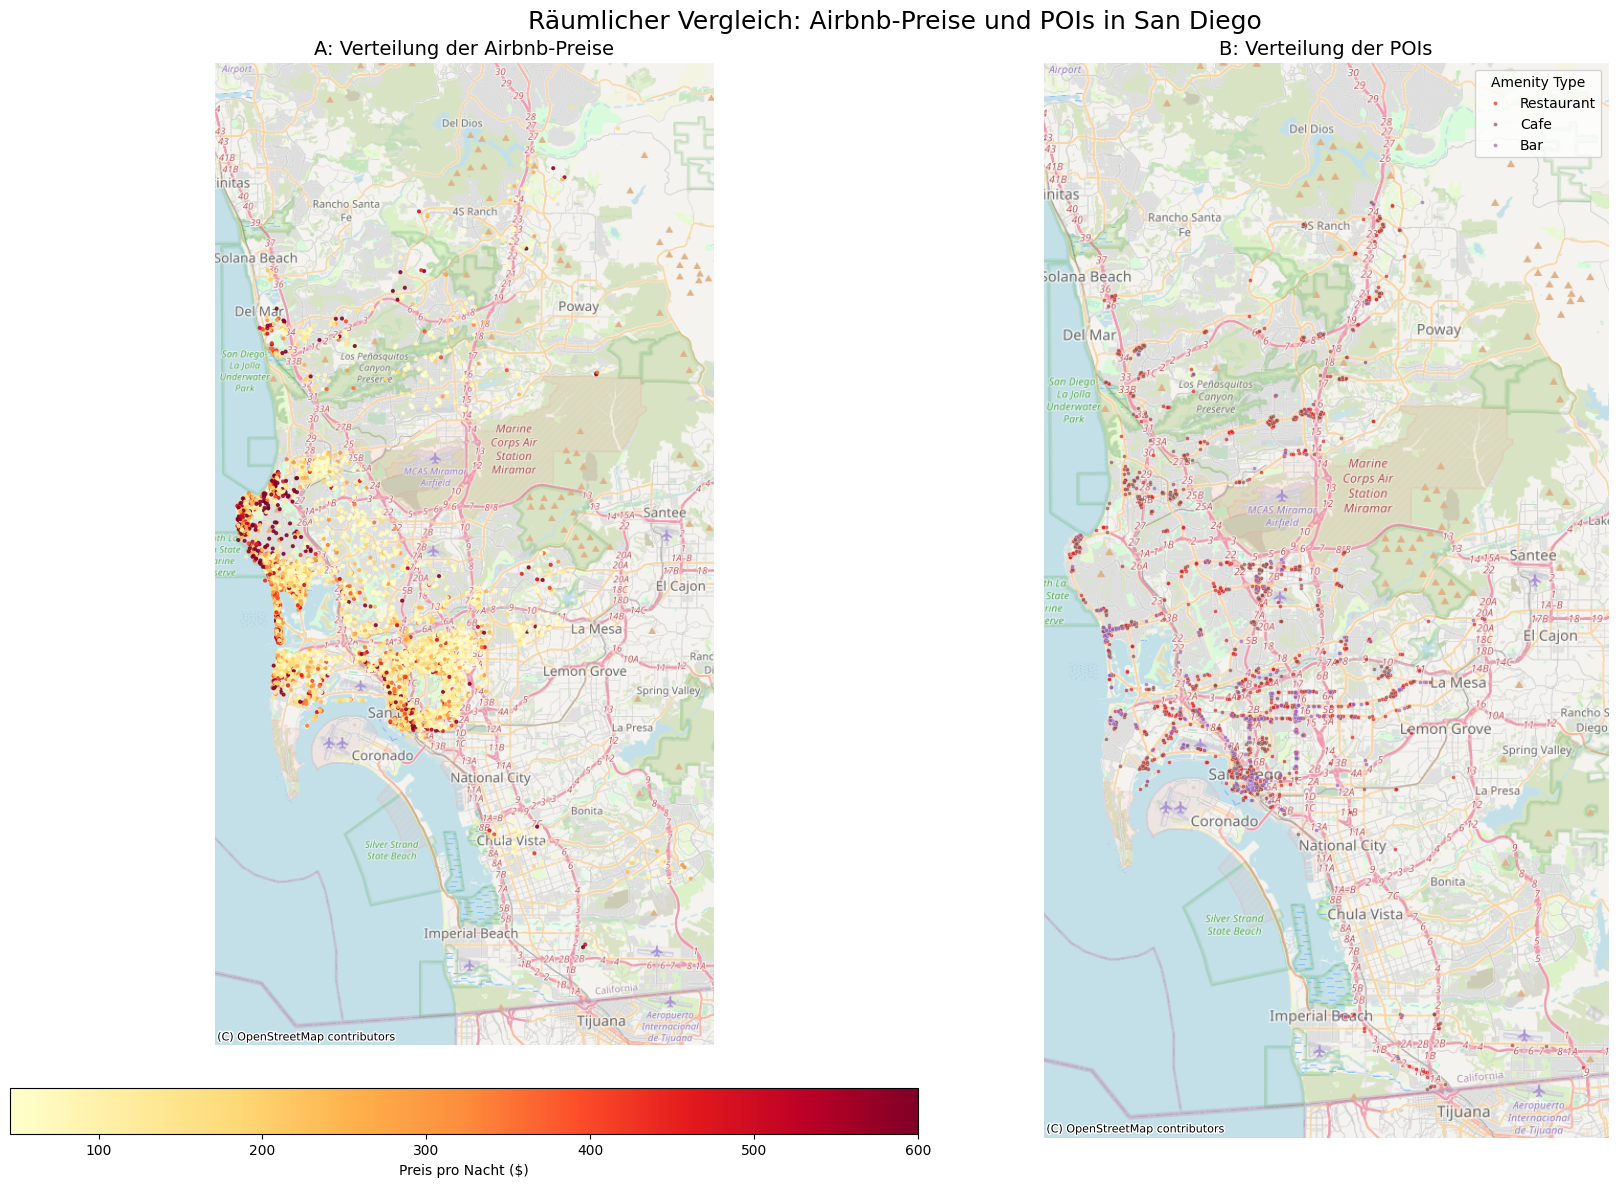

In [202]:
# Airbnbs und vorbereitete POI-Punkte in Web-Mercator transformieren,
# damit eine Basemap hinzugefügt werden kann
airbnb_3857 = airbnb.to_crs(epsg=3857)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12), sharey=True)

# Airbnb Plot
v_min, v_max = airbnb["price"].quantile(0.05), airbnb["price"].quantile(0.95)

airbnb_3857.plot(
    ax=ax1,
    column="price",
    cmap="YlOrRd",
    markersize=4,
    vmin=v_min,
    vmax=v_max,
    alpha=0.8
)

# POI Plot
amenity_colors = {
    "restaurant": "tab:red",
    "cafe": "tab:brown",
    "bar": "tab:purple"
}

for amenity, color in amenity_colors.items():
    subset = pois_3857[pois_3857["amenity"] == amenity]
    subset.plot(
        ax=ax2,
        color=color,
        markersize=8,
        label=amenity.capitalize(),
        alpha=0.7,
        edgecolor="white",
        linewidth=0.2
    )

# Basemap hinzufügen
for ax in [ax1, ax2]:
    cx.add_basemap(
        ax,
        source=cx.providers.OpenStreetMap.Mapnik,
        alpha=0.7,
        crs=airbnb_3857.crs
    )
    ax.set_axis_off()

# Farbskala für Airbnb-Preise
sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=v_min, vmax=v_max)
)

cbar = fig.colorbar(
    sm,
    ax=ax1,
    orientation="horizontal",
    fraction=0.046,
    pad=0.04
)

cbar.set_label("Preis pro Nacht ($)")

ax1.set_title("A: Verteilung der Airbnb-Preise", fontsize=14)
ax2.set_title("B: Verteilung der POIs", fontsize=14)
ax2.legend(title="Amenity Type", loc="upper right")

plt.suptitle("Räumlicher Vergleich: Airbnb-Preise und POIs in San Diego", fontsize=18, y=0.98)
plt.tight_layout()
plt.show()

Der direkte visuelle Vergleich zwischen der Airbnb Verteilung (A) und der POI Verteilung (B) zeigt eine erkennbare räumliche Kongruenz. 

Die Dichte der Amenities konzentriert sich in den Hochpreisgebieten, welche in Part 1 identifiziert wurden. Das unterstützt die Annahme, dass POIs relevant für die Preisgestaltung von AirBnBs sind. 

## 2.4 KDE-basierte POI-Features

Um die räumliche Nähe der AirBnB-Listings zu relevanten Points of Interest zu 
quantifizieren, berechnen wir für jede POI-Kategorie (Restaurants, Cafés, Bars) 
eine separate Kernel Density Estimation (KDE). Die KDE beschreibt, wie stark 
POIs einer Kategorie an einem bestimmten Ort konzentriert sind und überträgt 
diesen Dichte-Score auf jedes AirBnB-Listing.

Im Gegensatz zu einer einfachen Distanz zum nächstgelegenen POI berücksichtigt die KDE mehrere umliegende POIs gleichzeitig. Nahe POIs erhalten ein höheres Gewicht als weiter entfernte POIs. Dadurch entsteht für jedes Airbnb-Listing ein kontinuierlicher Dichte-Score.

Die resultierenden KDE-Werte werden abschließend mit einem MinMax-Scaler auf den 
Bereich [0, 1] normiert, um die drei Kategorien vergleichbar zu machen und eine 
optimale Grundlage für die nachfolgende Modellierung zu schaffen.

In [203]:
print(f"CRS AirBnB: {airbnb.crs}")
print(f"CRS POIS: {pois_sd.crs}")

CRS AirBnB: EPSG:4326
CRS POIS: EPSG:32611


Um sicherzustellen, dass Berechnugen korrekt durchgeführt werden, müssen wir alle Datensätze auf ein einheitliches Koordinatensystem bringen:

In [204]:
airbnb_sd = airbnb.to_crs(pois_sd.crs)

print(f"CRS AirBnB: {airbnb_sd.crs}")
print(f"CRS POIS: {pois_sd.crs}")

CRS AirBnB: EPSG:32611
CRS POIS: EPSG:32611


In [205]:
# helper function to convert the geometries into a suitable coordinate format for the KDE
def create_coordinate_array(geometries): 
    x_values = []
    y_values = []

# Iterate through each row in the GeoDataFrame
    for multipoint in geometries:
        # Ensure the geometry is indeed MultiPoint; if it's just a single Point, wrap it in a list
        points = list(multipoint.geoms) if hasattr(multipoint, "geoms") else [multipoint]
        
        # For each Point in the MultiPoint, extract x and y values
        for point in points:
            x_values.append(point.x)
            y_values.append(point.y)

    # Optionally, convert the lists to numpy arrays for further processing
    x_values = np.array(x_values)
    y_values = np.array(y_values)

    # Rearrange data to create a 2D array of x and y coordinates
    xy = np.vstack([x_values,y_values])

    return xy



airbnb_array = create_coordinate_array(airbnb_sd.geometry)

Für die KDE werden die POIs als Punktkoordinaten benötigt. Da die POIs bereits in repräsentative Punktgeometrien umgewandelt wurden, können ihre x- und y-Koordinaten direkt zur Schätzung der Dichtefunktion verwendet werden.

Die Airbnb-Listings selbst liegen ebenfalls als Punktgeometrien vor. Dadurch kann für jedes Listing berechnet werden, wie hoch die geschätzte POI-Dichte an genau diesem Standort ist.

Als Kernel-Funktion wird der Gauss-Kernel (`gaussian_kde`) verwendet. Dieser weist nahen POIs ein höheres Gewicht zu als weiter entfernten POIs, sodass eine geglättete Dichteoberfläche entsteht.

Die Bandwidth wird automatisch mittels Scott's Rule geschätzt. Dabei handelt es sich um eine etablierte Standardregel, die die Glättung in Abhängigkeit von Anzahl und Streuung der Punkte bestimmt. Die Wahl der Bandwidth beeinflusst die KDE deutlich: Eine kleinere Bandwidth erzeugt lokalere und detailreichere Dichtemuster, während eine größere Bandwidth zu einer stärker geglätteten Oberfläche führt.

Für diese Analyse wird die automatische Bandwidth verwendet, um ein reproduzierbares und datengetriebenes Vorgehen zu gewährleisten.

In [206]:
# KDE-Features für jede POI-Kategorie berechnen
for amenity in amenity_types:
    subset = pois_points[pois_points["amenity"] == amenity].copy()

    # Koordinaten der POIs dieser Kategorie
    poi_array = create_coordinate_array(subset.geometry)

    # KDE auf Basis der POI-Koordinaten schätzen
    kde = gaussian_kde(poi_array)

    # KDE-Werte an den Airbnb-Standorten berechnen
    kde_values = kde(airbnb_array)

    # Neue Feature-Spalte speichern
    col_name = f"kde_{amenity}"
    airbnb_sd[col_name] = kde_values

    print(
        f"Added column '{col_name}' | "
        f"n_pois={len(subset)} | "
        f"min={kde_values.min():.4e} | "
        f"mean={kde_values.mean():.4e} | "
        f"max={kde_values.max():.4e}"
    )

Added column 'kde_restaurant' | n_pois=1418 | min=4.4949e-14 | mean=2.7258e-09 | max=6.3806e-09
Added column 'kde_cafe' | n_pois=487 | min=5.2154e-13 | mean=2.3871e-09 | max=4.8256e-09
Added column 'kde_bar' | n_pois=284 | min=2.3753e-17 | mean=3.8484e-09 | max=8.8228e-09


Für jede POI-Kategorie wurde eine eigene KDE berechnet. Die resultierenden Werte beschreiben die geschätzte lokale Dichte der jeweiligen POI-Kategorie am Standort eines Airbnb-Listings.

Ein hoher KDE-Wert bedeutet, dass sich viele POIs dieser Kategorie in der Umgebung des Listings befinden. Ein niedriger Wert deutet dagegen auf eine geringere lokale Konzentration hin.

Die KDE-Werte sind zunächst rohe Dichtewerte und daher zwischen den Kategorien nicht direkt intuitiv vergleichbar. Deshalb werden sie in den modeling Schritten auf einen gemeinsamen Wertebereich zwischen 0 und 1 skaliert.

Die Skalierung verändert nicht die räumliche Reihenfolge der Listings, sondern macht die Features lediglich besser interpretierbar und für die spätere Modellierung vergleichbarer.

Zur Überprüfung der KDE-Ergebnisse visualisieren wir die AirBnB-Listings als 
räumliche Punktkarte, eingefärbt nach dem jeweiligen Dichte-Score. So lässt sich 
intuitiv prüfen, ob die berechneten KDE-Werte räumlich plausibel sind. 

AirBnBs im Stadtzentrum und an der Küste sollten erwartungsgemäß höhere Scores aufweisen 
als jene in peripheren Stadtgebieten.

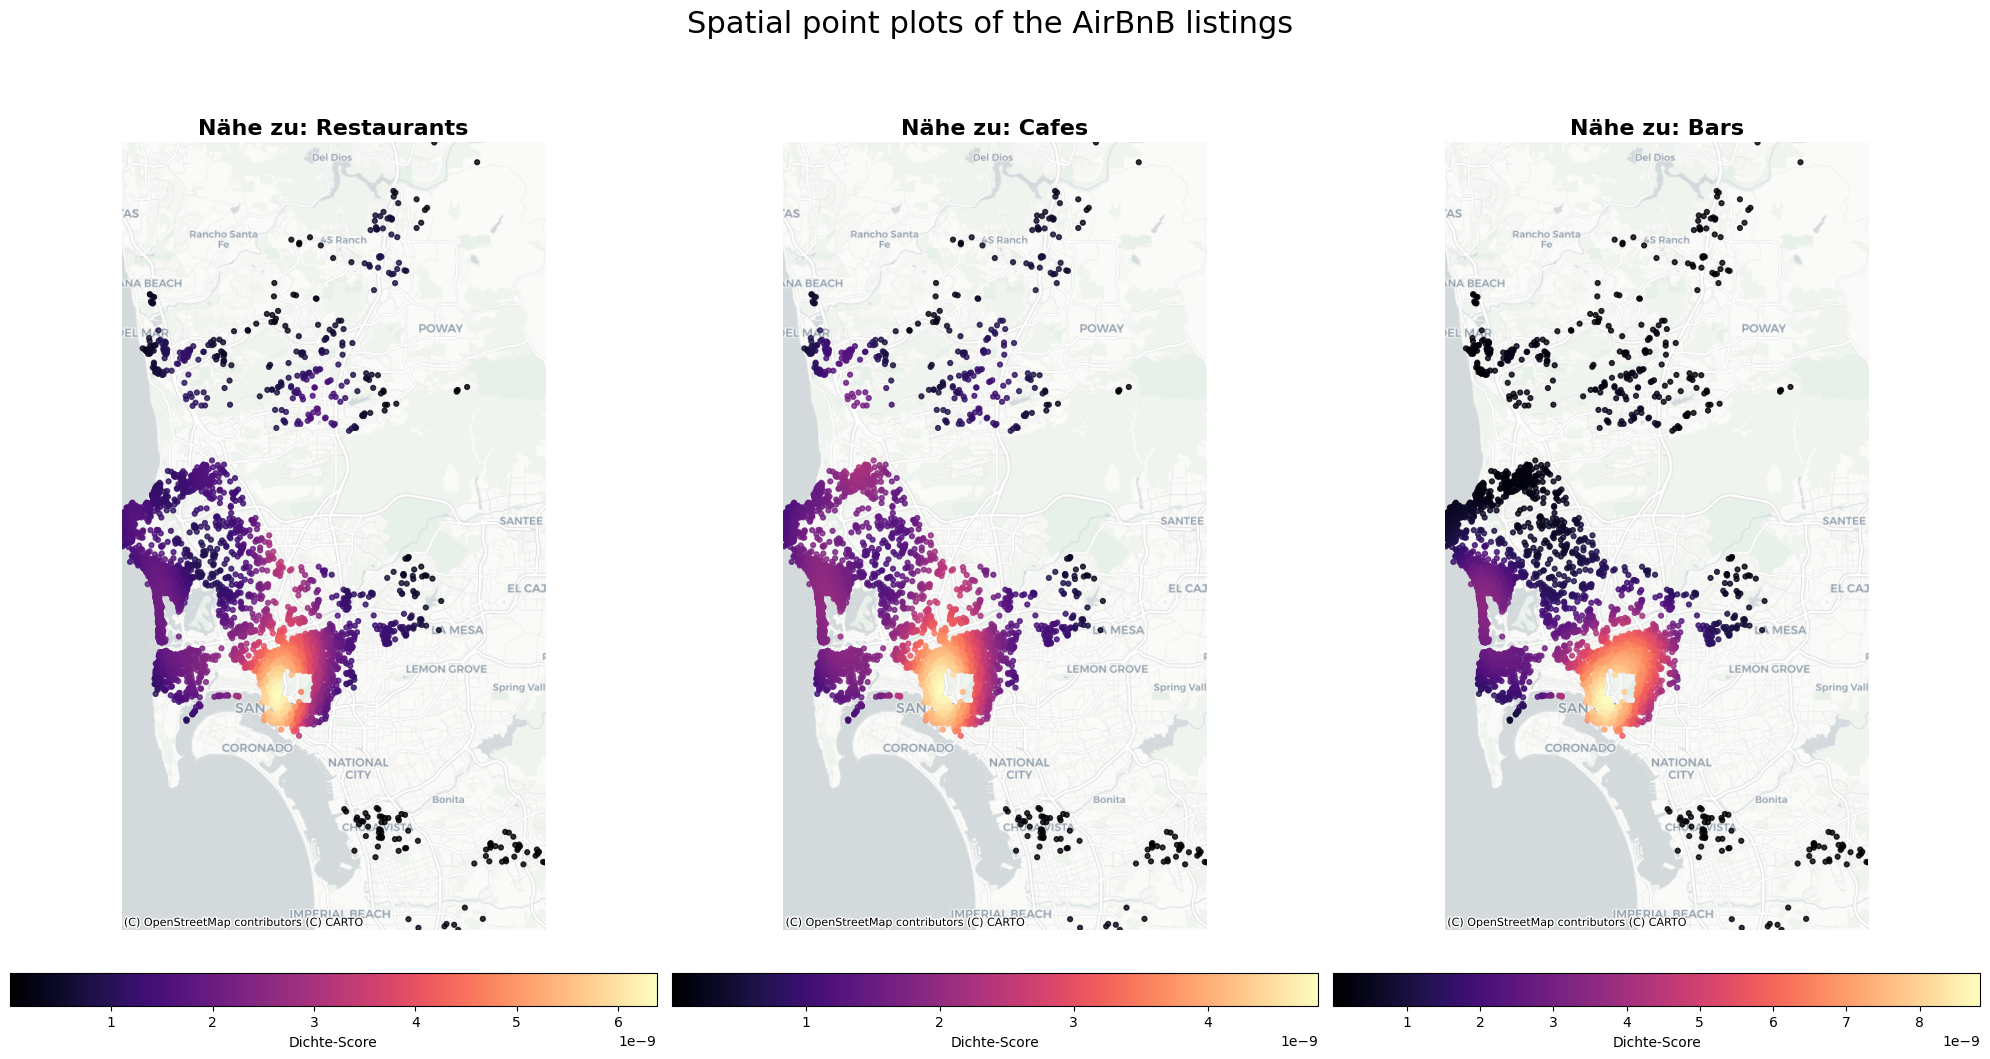

In [207]:
airbnb_3857 = airbnb_sd.to_crs(epsg=3857)

kde_cols = [f"kde_{a}" for a in amenity_types]

n_cols = len(kde_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(20, 10))

x_min, y_min, x_max, y_max = airbnb_3857.total_bounds

for i, col in enumerate(kde_cols):
    ax = axes[i]
    
    airbnb_3857.plot(
        ax=ax,
        column=col,
        cmap="magma",
        markersize=12,
        alpha=0.8,
        legend=True,
        legend_kwds={"label": "Dichte-Score", "orientation": "horizontal", "pad": 0.05, "fraction": 0.046}
    )

    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=airbnb_3857.crs)
    
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    title_name = col.replace("kde_", "").capitalize()
    ax.set_title(f"Nähe zu: {title_name}s", fontsize=16, fontweight='bold')
    ax.set_axis_off()

plt.suptitle("Spatial point plots of the AirBnB listings ", 
             fontsize=22, y=1.05)
plt.tight_layout()
plt.show()

Die Karten bestätigen die erwartete räumliche Struktur. AirBnB-Listings in der 
Nähe des Stadtzentrums und der Küste weisen durchgehend hohe Dichte-Scores auf,
unabhängig von der POI-Kategorie. Dies deckt sich mit der in Part 1 beobachteten 
Preisverteilung, wo dieselben Gebiete als Hochpreislagen identifiziert wurden.

AirBnBs im nördlichen und östlichen Stadtgebiet erhalten erwartungsgemäß niedrige 
Scores, da die gastronomische Infrastruktur dort deutlich geringer ist. Auffällig 
ist zudem, dass Bars räumlich stärker konzentriert sind als Restaurants oder Cafés, was sich in einem schärferen Dichte-Gradienten im entsprechenden Plot widerspiegelt.

Insgesamt liefert die KDE damit eine räumlich differenzierte Repräsentation der 
gastronomischen Erreichbarkeit. Das Feature wird im nachfolgenden Modellierungsschritt 
zur Vorhersage von AirBnB-Preisen eingesetzt.

## 2.5 Buffer-basierte POI-Features

Neben der KDE wird eine zweite Methode verwendet, um die räumliche Umgebung der Airbnb-Listings zu quantifizieren: buffer-basierte POI-Zählungen.

Dafür wird um jedes Airbnb-Listing ein Kreis mit einem festen Radius erstellt. Anschließend wird gezählt, wie viele Restaurants, Cafés und Bars innerhalb dieses Radius liegen. In dieser Analyse wird ein Radius von 1000 Metern verwendet. Dieser Radius ist groß genug, um die nähere Umgebung eines Listings abzubilden, bleibt aber noch interpretierbar als ungefähr fußläufig erreichbarer Bereich.

Im Gegensatz zur KDE verwendet die Buffer-Methode eine harte Distanzgrenze. POIs innerhalb des Radius zählen vollständig, POIs außerhalb des Radius zählen gar nicht. Die Methode ist dadurch einfacher zu interpretieren, aber weniger kontinuierlich als die KDE.

In [208]:
# Buffer um jedes Airbnb-Listing erstellen
buffer_radius = 1000  # meters

airbnb_buffers = airbnb_sd.copy()
airbnb_buffers["geometry"] = airbnb_buffers.geometry.buffer(buffer_radius)

Für jedes Airbnb-Listing wird ein Buffer mit einem Radius von 1000 Metern erstellt. Da die Daten in EPSG:32611 vorliegen, entspricht der Radius tatsächlich einer metrischen Distanz von 1000 Metern.

In [209]:
# POI-Anzahlen innerhalb des 1000-m-Buffers berechnen
for amenity in amenity_types:
    poi_subset = pois_points[pois_points["amenity"] == amenity].copy()

    joined = gpd.sjoin(
        airbnb_buffers[["geometry"]],
        poi_subset[["geometry", "amenity"]],
        how="left",
        predicate="contains"
    )

    # count() zählt nur tatsächliche Treffer und gibt bei fehlenden POIs den Wert 0 zurück
    counts = joined.groupby(joined.index)["amenity"].count()

    col_name = f"buffer1000_{amenity}_count"
    airbnb_sd[col_name] = counts.reindex(airbnb_sd.index, fill_value=0)

    print(
        f"Added column '{col_name}' | "
        f"min={airbnb_sd[col_name].min()} | "
        f"mean={airbnb_sd[col_name].mean():.2f} | "
        f"max={airbnb_sd[col_name].max()}"
    )

Added column 'buffer1000_restaurant_count' | min=0 | mean=26.71 | max=142
Added column 'buffer1000_cafe_count' | min=0 | mean=8.80 | max=44
Added column 'buffer1000_bar_count' | min=0 | mean=9.13 | max=51


In [210]:
# Buffer-Features zusammenfassen
buffer_cols = [f"buffer1000_{amenity}_count" for amenity in amenity_types]

airbnb_sd[buffer_cols].describe()

,buffer1000_restaurant_count,buffer1000_cafe_count,buffer1000_bar_count
count,6110.000000,6110.000000,6110.000000
mean,26.705237,8.801964,9.131751
std,31.488583,9.384795,12.838604
min,0.000000,0.000000,0.000000
25%,6.000000,2.000000,1.000000
50%,14.000000,6.000000,4.000000
75%,35.000000,12.000000,12.000000
max,142.000000,44.000000,51.000000


Die Buffer-Features geben direkt an, wie viele POIs einer Kategorie innerhalb von 1000 Metern um ein Airbnb-Listing liegen. Dadurch sind sie intuitiv interpretierbar: Ein höherer Wert bedeutet, dass sich mehr Restaurants, Cafés oder Bars in der näheren Umgebung befinden.

Gleichzeitig hängt das Ergebnis stark von der Wahl des Radius ab. Ein POI knapp innerhalb des Buffers wird vollständig gezählt, während ein POI knapp außerhalb des Buffers gar nicht berücksichtigt wird. Diese harte Grenze ist ein zentraler Unterschied zur KDE, bei der Entfernungen kontinuierlich gewichtet werden.

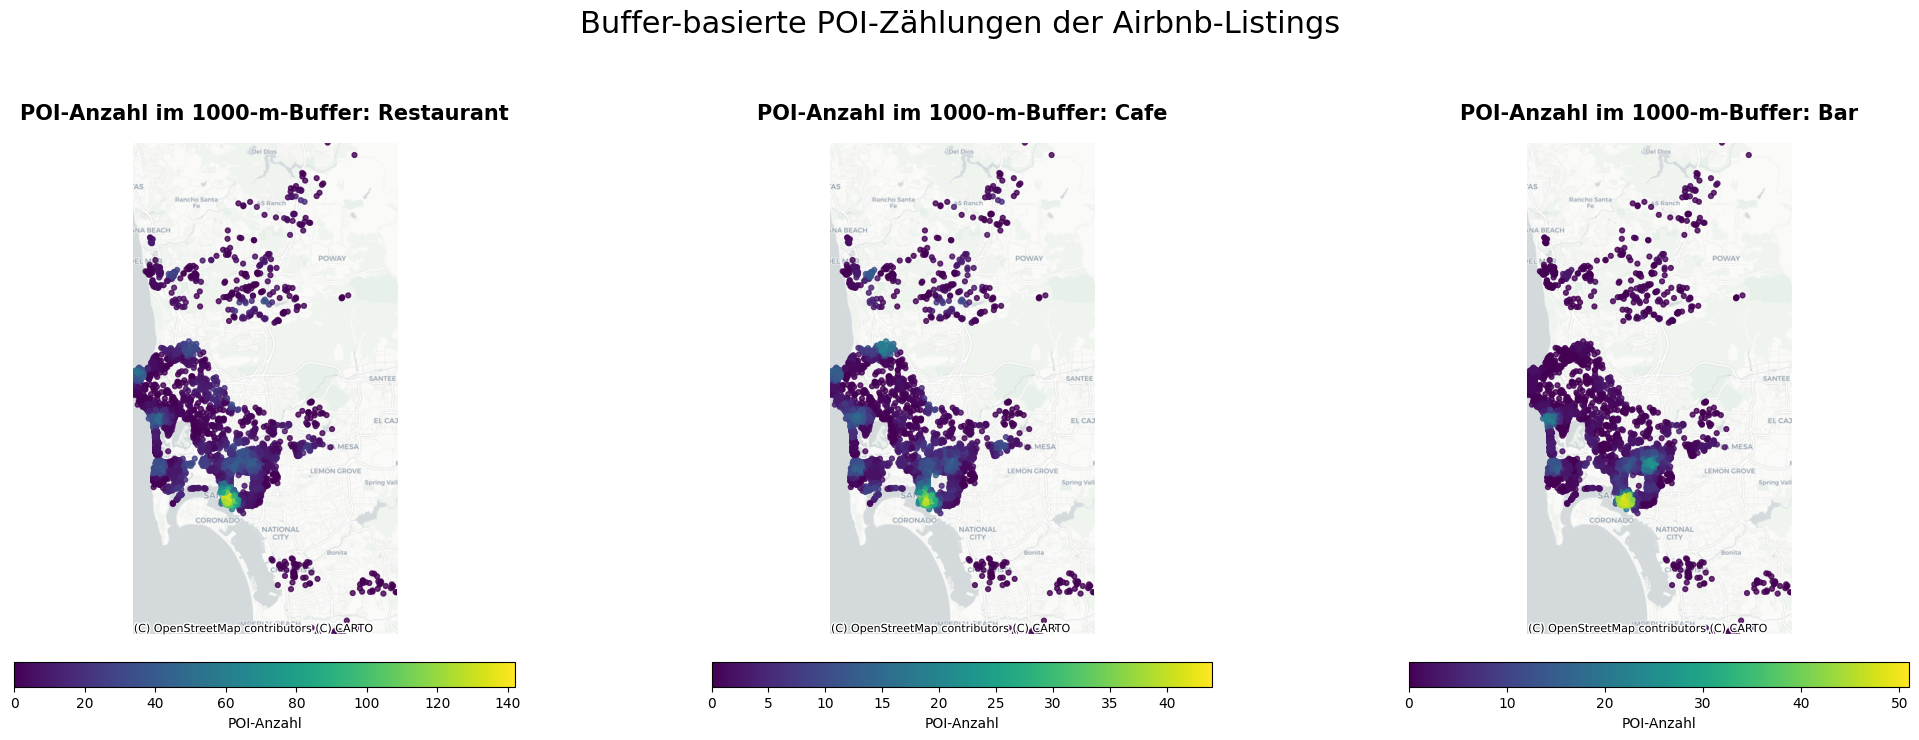

In [211]:
# Für Basemap-Visualisierung aktualisieren
airbnb_3857 = airbnb_sd.to_crs(epsg=3857)

fig, axes = plt.subplots(1, len(buffer_cols), figsize=(21, 7))

x_min, y_min, x_max, y_max = airbnb_3857.total_bounds

for ax, col in zip(axes, buffer_cols):
    airbnb_3857.plot(
        ax=ax,
        column=col,
        cmap="viridis",
        markersize=12,
        alpha=0.8,
        legend=True,
        legend_kwds={
            "label": "POI-Anzahl",
            "orientation": "horizontal",
            "pad": 0.05,
            "fraction": 0.046
        }
    )

    cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, crs=airbnb_3857.crs)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    title_name = col.replace("buffer1000_", "").replace("_count", "").capitalize()
    ax.set_title(f"POI-Anzahl im 1000-m-Buffer: {title_name}", fontsize=15, fontweight="bold")
    ax.set_axis_off()

plt.suptitle("Buffer-basierte POI-Zählungen der Airbnb-Listings", fontsize=22, y=1.05)
plt.tight_layout()
plt.show()

Die Karten zeigen die Anzahl der POIs innerhalb eines 1000-Meter-Radius um jedes Airbnb-Listing. Hohe Werte treten vor allem dort auf, wo gastronomische Angebote räumlich stark konzentriert sind.

Die räumlichen Muster ähneln grundsätzlich den KDE-Karten, da beide Ansätze dieselbe POI-Verteilung abbilden. Der Unterschied liegt jedoch in der Berechnung: Die Buffer-Methode zählt POIs innerhalb einer festen Distanz, während die KDE eine geglättete Dichte schätzt.

Dadurch sind Buffer-Features direkter interpretierbar, aber stärker von der gewählten Distanzgrenze abhängig. KDE-Features sind weniger unmittelbar als Anzahl interpretierbar, bilden räumliche Übergänge dafür kontinuierlicher ab.

## 2.6 Vergleich von KDE- und Buffer-Features

Da KDE- und Buffer-Features aus denselben POI-Daten abgeleitet werden, ist zu erwarten, dass sie teilweise ähnliche räumliche Informationen enthalten.

Ein kurzer Vergleich der Korrelationen zeigt, wie stark die beiden Ansätze zusammenhängen und ob sie möglicherweise ähnliche oder ergänzende Informationen liefern.

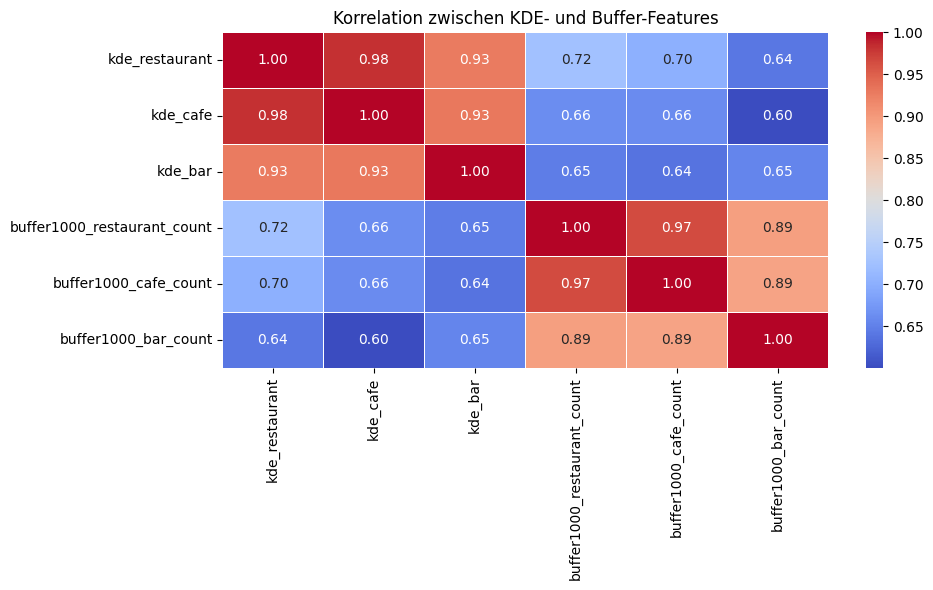

In [212]:
# Korrelation zwischen KDE- und Buffer-Features untersuchen
comparison_cols = kde_cols + buffer_cols

plt.figure(figsize=(10, 6))

sns.heatmap(
    airbnb_sd[comparison_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Korrelation zwischen KDE- und Buffer-Features")
plt.tight_layout()
plt.show()

Die Korrelationen zwischen KDE- und Buffer-Features zeigen, inwiefern beide Methoden ähnliche räumliche Informationen abbilden. Hohe positive Korrelationen sind plausibel, da beide Ansätze auf denselben POI-Kategorien basieren.

Der spätere Modellvergleich kann zeigen, ob die kontinuierlichen KDE-Scores oder die einfacher interpretierbaren Buffer-Zählungen für die Preisvorhersage hilfreicher sind.

### Zwischenfazit zu Part 2

In Part 2 wurden zusätzliche räumliche Features erstellt, um die Umgebung der Airbnb-Listings besser abzubilden. Dafür wurden Restaurants, Cafés und Bars aus OpenStreetMap heruntergeladen, auf das Stadtgebiet von San Diego begrenzt und in ein metrisches Koordinatensystem transformiert.

Die explorative räumliche Analyse zeigt, dass diese POIs nicht gleichmäßig verteilt sind, sondern sich besonders in zentralen, urbanen und touristisch attraktiven Bereichen konzentrieren. Diese räumlichen Muster sprechen dafür, dass gastronomische Infrastruktur ein relevantes Standortmerkmal für Airbnb-Preise sein könnte.

Zur Quantifizierung dieser Umgebung wurden zwei Feature-Typen erstellt. Die KDE-Features messen die lokale Dichte von Restaurants, Cafés und Bars in kontinuierlicher Form. Die Buffer-Features zählen dagegen, wie viele POIs innerhalb eines festen Radius von 1000 Metern um ein Listing liegen.

Beide Ansätze haben unterschiedliche Vorteile. KDE-Features bilden räumliche Übergänge glatter ab und vermeiden harte Distanzgrenzen. Buffer-Features sind dafür einfacher zu interpretieren, da sie direkte POI-Anzahlen in der näheren Umgebung darstellen.

In Part 3 können diese Features nun systematisch in die Modellierung integriert werden. Dabei kann verglichen werden, ob die zusätzlichen räumlichen Informationen die Vorhersage der Airbnb-Preise verbessern und ob KDE- oder Buffer-Features den größeren Beitrag leisten.

# PART 3: Modeling and Analysis 

In diesem Teil werden die Airbnb-Preise mithilfe verschiedener Machine-Learning-Modelle vorhergesagt. Ziel ist es nicht nur, ein möglichst genaues Modell zu trainieren, sondern auch zu prüfen, ob die in Part 2 erstellten räumlichen Features die Vorhersage verbessern.

Dafür werden drei Modelltypen miteinander verglichen:

1. **Triviale Baseline** — die Vorhersage erfolgt konstant über den Mittelwert der Zielvariable.

2. **Random-Forest-Regressor** — ein Ensembleverfahren auf Basis von Entscheidungsbäumen, das in der Lage ist, komplexe nichtlineare Zusammenhänge sowie Interaktionseffekte zwischen Variablen zu modellieren.

3. **XGBoost** — ein gradientenbasiertes Boosting-Verfahren, bei dem Entscheidungsbäume sequenziell trainiert werden, sodass nachfolgende Modelle gezielt die Fehler der vorherigen Modelle korrigieren. Dadurch kann häufig eine besonders hohe Prognosegenauigkeit erreicht werden.

### Begründung der Modellwahl

Die Modellwahl folgt einer aufsteigenden Komplexitätslogik: 

Die triviale Baseline dient als untere Schranke, die jedes sinnvolle Modell übertreffen muss. 

Der Random Forest wurde gewählt, da er ohne aufwendiges Preprocessing auskommt, robust gegenüber Ausreißern ist und durch Feature Importances interpretierbar bleibt 

XGBoost ergänzt den Vergleich als gradientenbasiertes Boosting-Verfahren, das bei tabellarischen Daten häufig eine höhere Prognosegenauigkeit als Random Forest erzielt, da es Fehler iterativ korrigiert. 

Deep-Learning-Ansätze wurden bewusst nicht berücksichtigt, da die verfügbare Datenmenge für solche Verfahren zu gering ist und tabellarische Daten dieser Dimensionalität keinen nennenswerten Vorteil durch tiefe Architekturen erwarten lassen.

### Feature sets

Zusätzlich werden unterschiedliche Feature Sets getestet:

- **Feature Set A:** nur strukturelle Listing-Merkmale
- **Feature Set B:** strukturelle Merkmale + KDE-Features
- **Feature Set C:** strukturelle Merkmale + Buffer-Features

Damit kann untersucht werden, ob räumliche Informationen die Preisvorhersage verbessern und ob kontinuierliche KDE-Dichten oder einfacher interpretierbare Buffer-Zählungen hilfreicher sind.

### Error metric

Um die Vorhersagegenauigkeit zu evaluieren verwenden wir den **Root Mean Squared Error (RMSE)** sowie den **Mean Absolute Error (MAE)**. 

Beide Metriken geben den Prognosefehler in einer gut interpretierbaren Einheit (USD pro Nacht) an und ermöglichen somit eine direkte ökonomische Einordnung der Modellgüte.

In [213]:
#imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, KFold
from xgboost import XGBRegressor

In [214]:
# Basisfeatures aus den ursprünglichen Listing-Daten
basic_features = [
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "rt_Private_room",
    "rt_Shared_room",
    "pg_Condominium",
    "pg_House",
    "pg_Other",
    "pg_Townhouse",
]

# Räumliche Features aus Part 2
kde_features = [
    "kde_restaurant",
    "kde_cafe",
    "kde_bar",
]

buffer_features = [
    "buffer1000_restaurant_count",
    "buffer1000_cafe_count",
    "buffer1000_bar_count",
]

# Feature Sets für den Modellvergleich
features_A = basic_features
features_B = basic_features + kde_features
features_C = basic_features + buffer_features

# Optional, falls du KDE und Buffer gemeinsam testen möchtest:
# features_D = basic_features + kde_features + buffer_features

# Prüfung auf fehlende Werte
all_model_features = sorted(set(features_A + features_B + features_C))
missing_count = airbnb_sd[all_model_features + ["price"]].isna().sum()

missing_count

accommodates                   0
bathrooms                      0
bedrooms                       0
beds                           0
buffer1000_bar_count           0
buffer1000_cafe_count          0
buffer1000_restaurant_count    0
kde_bar                        0
kde_cafe                       0
kde_restaurant                 0
pg_Condominium                 0
pg_House                       0
pg_Other                       0
pg_Townhouse                   0
rt_Private_room                0
rt_Shared_room                 0
price                          0
dtype: int64

Die Prüfung zeigt, ob in den für die Modellierung verwendeten Variablen fehlende Werte vorhanden sind. Da keine relevanten Missing Values auftreten, ist keine Imputation erforderlich.

Ein zusätzliches Encoding ist ebenfalls nicht notwendig, da alle verwendeten Variablen entweder numerisch vorliegen oder bereits als Dummy-Variablen codiert sind.

Die Feature Sets sind so aufgebaut, dass der Mehrwert der räumlichen Features systematisch getestet werden kann. Feature Set A enthält nur die ursprünglichen Listing-Merkmale. Feature Set B ergänzt die KDE-Features, während Feature Set C die buffer-basierten POI-Zählungen enthält. Dadurch kann später direkt verglichen werden, ob KDE oder Buffer die Preisvorhersage stärker verbessern.

### Train- und Testdaten

Der Datensatz wird einmalig in Trainings- und Testdaten aufgeteilt. Dabei werden 80 % der Beobachtungen für das Training und 20 % für die finale Evaluation verwendet.

Die einmalige Aufteilung zu Beginn stellt sicher, dass alle Modelle und Feature Sets auf exakt denselben Beobachtungen trainiert und getestet werden. Dadurch sind die Ergebnisse fair vergleichbar.

Der `random_state=67` garantiert die Reproduzierbarkeit der Aufteilung. Der Testdatensatz wird erst nach dem Training und Hyperparameter-Tuning verwendet, um eine möglichst unverzerrte Einschätzung der Generalisierungsfähigkeit zu erhalten.

In [215]:
# Gesamten Datensatz einmalig splitten, damit alle Modelle fair vergleichbar sind
train_df, test_df = train_test_split(
    airbnb_sd,
    test_size=0.2,
    random_state=67
)

# MinMaxScaler nur auf Trainingsdaten fitten, dann auf beide anwenden
scaler = MinMaxScaler()
train_df[kde_cols] = scaler.fit_transform(train_df[kde_cols])
test_df[kde_cols]  = scaler.transform(test_df[kde_cols])

# Feature Sets und Zielvariable definieren
X_A_train = train_df[features_A]
X_B_train = train_df[features_B]
X_C_train = train_df[features_C]

X_A_test = test_df[features_A]
X_B_test = test_df[features_B]
X_C_test = test_df[features_C]

y_train = train_df["price"]
y_test = test_df["price"]

airbnb_sd[kde_cols].describe()

print(f"Training samples: {len(train_df)}")
print(f"Test samples:     {len(test_df)}")

Training samples: 4888
Test samples:     1222


In [216]:
X_A_train.head()

,accommodates,bathrooms,bedrooms,beds,rt_Private_room,rt_Shared_room,pg_Condominium,pg_House,pg_Other,pg_Townhouse
5373,5,2.0,2.0,2.0,0,0,0,0,1,0
3998,2,1.0,1.0,1.0,1,0,0,1,0,0
3140,3,3.0,1.0,1.0,0,0,0,0,1,0
4344,2,1.0,0.0,1.0,0,0,0,0,0,0
3992,2,1.0,1.0,1.0,0,1,0,0,0,0


In [217]:
X_B_train.head()

,accommodates,bathrooms,bedrooms,beds,rt_Private_room,rt_Shared_room,pg_Condominium,pg_House,pg_Other,pg_Townhouse,kde_restaurant,kde_cafe,kde_bar
5373,5,2.0,2.0,2.0,0,0,0,0,1,0,0.249423,0.271260,0.105587
3998,2,1.0,1.0,1.0,1,0,0,1,0,0,0.321923,0.385178,0.329949
3140,3,3.0,1.0,1.0,0,0,0,0,1,0,0.901661,0.939939,0.972420
4344,2,1.0,0.0,1.0,0,0,0,0,0,0,0.409671,0.469421,0.660424
3992,2,1.0,1.0,1.0,0,1,0,0,0,0,0.316854,0.375249,0.538659


In [218]:
X_C_train.head()

,accommodates,bathrooms,bedrooms,beds,rt_Private_room,rt_Shared_room,pg_Condominium,pg_House,pg_Other,pg_Townhouse,buffer1000_restaurant_count,buffer1000_cafe_count,buffer1000_bar_count
5373,5,2.0,2.0,2.0,0,0,0,0,1,0,21,4,1
3998,2,1.0,1.0,1.0,1,0,0,1,0,0,22,9,10
3140,3,3.0,1.0,1.0,0,0,0,0,1,0,85,29,41
4344,2,1.0,0.0,1.0,0,0,0,0,0,0,18,9,17
3992,2,1.0,1.0,1.0,0,1,0,0,0,0,11,7,8


In [219]:
from sklearn.metrics import r2_score

#helper function um Metriken zu berechenen und darzustellen 
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:<40} RMSE={rmse:7.2f}  MAE={mae:7.2f}  R²={r2:.3f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []
results_in_sample = []

## Model 1: Trivial Baseline

Als einfachstes Referenzmodell wird zunächst der Mittelwert der Zielvariable im Trainingsdatensatz berechnet. 

Dieser konstante Wert wird anschließend für alle Beobachtungen im Testdatensatz als Vorhersage verwendet. Das Modell ignoriert somit sämtliche Eingangsmerkmale und dient als naive Vergleichsbasis, an der die Güte komplexerer Modelle gemessen wird. 

Die resultierenden Fehlermaße (RMSE und MAE) definieren eine untere Benchmark für sinnvolle Prognosemodelle.

In [220]:
# Trivial baseline: Predict always the mean price 
mean_price = y_train.mean()
y_pred_baseline = np.full(len(y_test), mean_price)   #array mit der Länge der test Daten, nur mit mean als Wert

print(f"Mean training price: {mean_price:.2f}")
results.append(evaluate("Baseline (mean predictor)", y_test, y_pred_baseline))

Mean training price: 217.02
Baseline (mean predictor)                RMSE= 261.18  MAE= 146.04  R²=-0.000


## Model 2: Random Forest Regressor

Als zweites Modell wird ein Random Forest verwendet. Der Random Forest ist ein Ensembleverfahren, das viele Entscheidungsbäume kombiniert und dadurch robuste Vorhersagen erzeugen kann. Er eignet sich gut für tabellarische Daten und kann nichtlineare Zusammenhänge sowie Interaktionen zwischen Variablen abbilden.

Da die Zielvariable `price` in Part 1 als stark rechtsschief identifiziert wurde, wird für das Training eine Log-Transformation verwendet. Dadurch wird der Einfluss extrem teurer Listings reduziert. Die Modelle lernen somit eher relative Preisunterschiede.

Für die finale Evaluation werden die vorhergesagten Werte anschließend mit `np.expm1()` zurück in die ursprüngliche Dollar-Skala transformiert. RMSE, MAE und R² werden dadurch auf der realen Preisskala interpretiert.

In [221]:
y_train_log = np.log1p(y_train)

# Cross validation
kf = KFold(n_splits=10, shuffle=True, random_state=67)

# Parameter
estimators_range = [50, 100, 200, 300]

mae_means_A = []
r2_means_A = []

for n in estimators_range:
    rf_A = RandomForestRegressor(n_estimators=n, random_state=67)

    # MAE
    mae_scores_A = cross_val_score(
        rf_A,
        X_A_train,
        y_train_log,
        cv=kf,
        scoring="neg_mean_absolute_error"
    )
    mae_scores_A = -mae_scores_A  # zurücktransformieren zu positiven MAE-Werten

    # R2
    r2_scores_A = cross_val_score(
        rf_A,
        X_A_train,
        y_train_log,
        cv=kf,
        scoring="r2"
    )

    mae_means_A.append(mae_scores_A.mean())
    r2_means_A.append(r2_scores_A.mean())

    print(f"n={n} | MAE={mae_scores_A.mean():.4f} | R²={r2_scores_A.mean():.4f} | (+/- {r2_scores_A.std():.4f})")

# Bestes Modell nach MAE (Fehler minimieren!)
best_n = estimators_range[np.argmin(mae_means_A)]
print(f"\nBest n_estimators (nach MAE): {best_n}")

n=50 | MAE=0.3507 | R²=0.6571 | (+/- 0.0290)
n=100 | MAE=0.3498 | R²=0.6592 | (+/- 0.0287)
n=200 | MAE=0.3495 | R²=0.6599 | (+/- 0.0286)
n=300 | MAE=0.3493 | R²=0.6603 | (+/- 0.0287)

Best n_estimators (nach MAE): 300


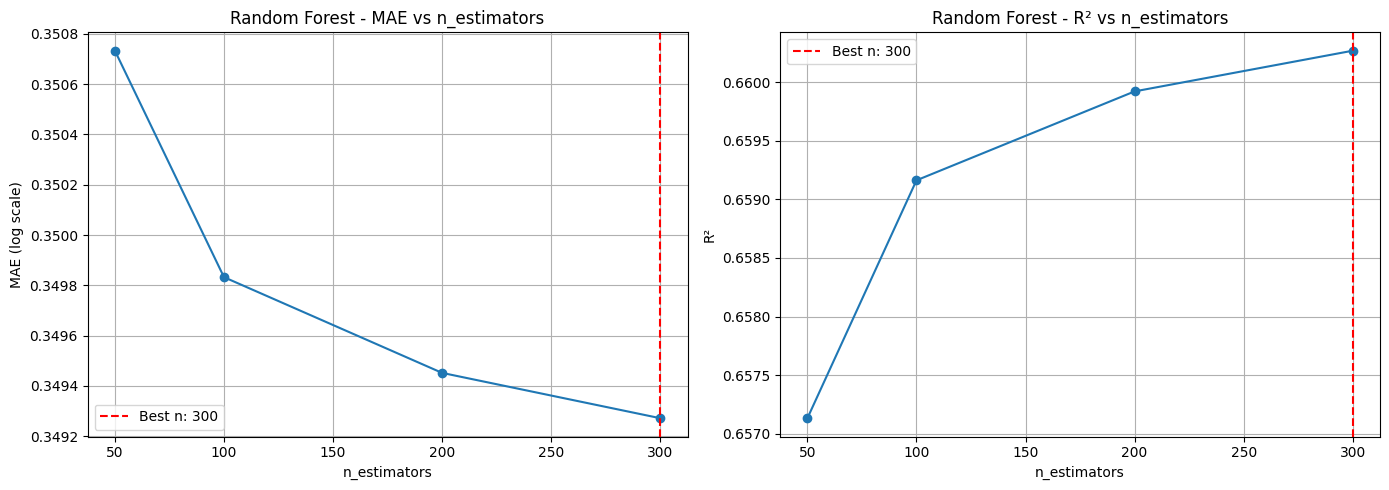

In [222]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))


ax[0].plot(estimators_range, mae_means_A, marker='o')
ax[0].set_title("Random Forest - MAE vs n_estimators")
ax[0].set_xlabel("n_estimators")
ax[0].set_ylabel("MAE (log scale)")
ax[0].grid(True)
ax[0].axvline(best_n, linestyle="--", color="red", label=f"Best n: {best_n}")
ax[0].legend()


ax[1].plot(estimators_range, r2_means_A, marker='o')
ax[1].set_title("Random Forest - R² vs n_estimators")
ax[1].set_xlabel("n_estimators")
ax[1].set_ylabel("R²")
ax[1].grid(True)
ax[1].axvline(best_n, linestyle="--", color="red", label=f"Best n: {best_n}")
ax[1].legend()

plt.tight_layout()
plt.show()

Die Kreuzvalidierung zeigt, wie sich die Modellgüte bei unterschiedlicher Anzahl von Bäumen verändert. Als Auswahlkriterium wird der MAE auf der log-transformierten Zielvariable verwendet, da ein geringerer Fehler direkt auf eine bessere durchschnittliche Prognose hinweist.

Da der Zielwert für das Training logarithmiert wurde, ist der MAE in dieser Cross-Validation nicht direkt in Dollar interpretierbar. Er dient hier vor allem dazu, verschiedene Hyperparameter-Einstellungen innerhalb desselben Modelltyps zu vergleichen.

Die ausgewählte Anzahl an Bäumen wird anschließend für alle Random-Forest-Modelle verwendet. Dadurch unterscheiden sich die Modelle nur im Feature Set, nicht aber in der Modellkomplexität.

### Modell A:

In [223]:
#rf modell mit optimaler tree anzahl trainieren und vorhersagen machen 
rf_model_A = RandomForestRegressor(n_estimators=best_n, random_state=67)

rf_model_A.fit(X_A_train, y_train_log)

y_pred_rf_A_log = rf_model_A.predict(X_A_test)
y_pred_rf_A_log_is = rf_model_A.predict(X_A_train)

#zurück transformieren und evaluieren
y_pred_rf_A = np.expm1(y_pred_rf_A_log)
y_pred_rf_A_is = np.expm1(y_pred_rf_A_log_is)

results_in_sample.append(evaluate("Random Forest (features_A in sample)", y_train, y_pred_rf_A_is))
results.append(evaluate("Random Forest (feature set A)", y_test, y_pred_rf_A))

Random Forest (features_A in sample)     RMSE= 135.14  MAE=  58.98  R²=0.769
Random Forest (feature set A)            RMSE= 180.63  MAE=  82.82  R²=0.521


Die Evaluierung des Random Forest Modells auf Basis von Feature Set A zeigt eine verlässliche und robuste Vorhersage. In der 10 Fold Crossvalidation auf der log-transformierten Zielvariable erzielt das modell einen durchschnittlichen R2 Score von 0.6603. Die geringe Standardabweichung von (+/- 0.0287) belegt die Stabilität des Modells. Es zeigt sich also kein Hinweis auf starkes Overfitting. 

Nach der Rücktransformation der Vorhersagen in die ursprüngliche Preisskala zeigt sich ein MAE von 82.82 USD. Auffällig ist jedoch die deutliche Diskrepanz zum RMSE in Höhe von 180.63 USD. 

In Relation zum mittleren AirBnB-Preis von 217.02 USD ist 
dieser Wert als hoch einzustufen. Ein Hinweis darauf, dass das Modell einzelne 
Listings stark über- oder unterschätzt, deren Preis auf Merkmale zurückzuführen ist, 
die im vorliegenden Datensatz nicht erfasst sind. 

### Modell B: 

Modell B wird mit derselben Random-Forest-Konfiguration wie Modell A trainiert. Lediglich das Feature Set wird um die drei KDE-Features erweitert. Dadurch lässt sich prüfen, ob die kontinuierlichen POI-Dichtewerte aus Part 2 die Preisvorhersage verbessern. Somit wird der isolierte Effekt der räumlichen Features sauber gemessen.

In [224]:
#rf model B mit optimaler tree anzahl trainieren und vorhersagen machen
rf_model_B = RandomForestRegressor(n_estimators=best_n, random_state=67)

rf_model_B.fit(X_B_train, y_train_log)

y_pred_rf_B_log = rf_model_B.predict(X_B_test)
y_pred_rf_B_log_is = rf_model_B.predict(X_B_train)

#zurück transformieren und evaluieren
y_pred_rf_B = np.expm1(y_pred_rf_B_log)
y_pred_rf_B_is = np.expm1(y_pred_rf_B_log_is)

results_in_sample.append(evaluate("Random Fores (features_B in sample)", y_train, y_pred_rf_B_is))
results.append(evaluate("Random Forest (feature set B)", y_test, y_pred_rf_B))

Random Fores (features_B in sample)      RMSE=  97.92  MAE=  30.56  R²=0.879
Random Forest (feature set B)            RMSE= 172.78  MAE=  74.58  R²=0.562


Die Integration der KDE-Features in Feature Set B führt im Vergleich zu Feature Set A zu einer messbaren Verbesserung der Modellgüte. Der RMSE sinkt von 180.63 USD auf 172.78 USD, der MAE von 82.82 USD auf 74.58 USD.

Dies unterstützt die Annahme, dass räumliche Informationen zur gastronomischen Umgebung eines Listings zusätzliche Erklärungskraft für die Airbnb-Preise besitzen. Die KDE-Features bilden dabei nicht die direkte Entfernung zu einzelnen POIs ab, sondern die lokale Dichte von Restaurants, Cafés und Bars.

Die verbleibende Diskrepanz zwischen MAE und RMSE deutet jedoch darauf hin, dass auch Modell B einzelne Listings weiterhin deutlich falsch einschätzt. Insbesondere sehr teure oder ungewöhnliche Unterkünfte können die Fehlermaße stark beeinflussen. Weitere nicht erfasste Merkmale wie Ausstattung, Bewertungen, Qualität, Saison oder direkte Küstennähe könnten die Vorhersagegenauigkeit zusätzlich verbessern.

Im nächsten Schritt wird mit Feature Set C geprüft, ob buffer-basierte POI-Zählungen eine ähnliche oder stärkere Verbesserung liefern als die KDE-Features.

### Modell C: 

Modell C erweitert die Basisfeatures nicht um KDE-Scores, sondern um die buffer-basierten POI-Zählungen. Dadurch kann geprüft werden, ob die einfacher interpretierbaren Buffer-Features eine ähnliche oder bessere Modellverbesserung liefern als die KDE-Features.

Auch hier bleibt die Modellkonfiguration identisch. Der Unterschied zwischen Modell A, B und C liegt ausschließlich im verwendeten Feature Set.

In [225]:
# Random Forest Modell C mit Buffer-Features trainieren
rf_model_C = RandomForestRegressor(n_estimators=best_n, random_state=67)

rf_model_C.fit(X_C_train, y_train_log)

# Vorhersagen auf Test- und Trainingsdaten
y_pred_rf_C_log = rf_model_C.predict(X_C_test)
y_pred_rf_C_log_is = rf_model_C.predict(X_C_train)

# Rücktransformation in Dollar-Skala
y_pred_rf_C = np.expm1(y_pred_rf_C_log)
y_pred_rf_C_is = np.expm1(y_pred_rf_C_log_is)

results_in_sample.append(evaluate("Random Forest (feature set C in sample)", y_train, y_pred_rf_C_is))
results.append(evaluate("Random Forest (feature set C)", y_test, y_pred_rf_C))

Random Forest (feature set C in sample)  RMSE= 103.38  MAE=  33.23  R²=0.865
Random Forest (feature set C)            RMSE= 178.96  MAE=  79.71  R²=0.530


Die Ergebnisse von Modell C zeigen, ob die buffer-basierten POI-Zählungen zusätzliche Erklärungskraft gegenüber den reinen Listing-Merkmalen liefern.

Wenn Modell C ähnlich gut oder besser abschneidet als Modell B, spricht dies dafür, dass die direkte Anzahl nahegelegener POIs bereits einen großen Teil der räumlichen Information erfasst. Wenn Modell B besser abschneidet, deutet dies darauf hin, dass die kontinuierliche Gewichtung der KDE vorteilhaft ist.

## Model 3: XGBoost Regressor

Ergänzend zum Random Forest wird ein XGBoost-Modell trainiert. Während Random Forest viele Bäume parallel und unabhängig voneinander aufbaut, lernt XGBoost 
sequenziell. Jeder neue Baum korrigiert dabei die Fehler des vorherigen. Dies macht XGBoost besonders leistungsfähig bei komplexen, nicht-linearen Zusammenhängen und führt in der Praxis häufig zu einer höheren Vorhersagegenauigkeit. 

Der Vergleich beider Ansätze erlaubt eine fundiertere Aussage darüber, welches Modell die AirBnB-Preise in San Diego am besten erklärt.

### Hyperparameter-Tuning: XGBoost

Die relevanten Parameter und ihre Bedeutung:

| Parameter | Bedeutung |
|---|---|
| `n_estimators` | Anzahl der sequenziell trainierten Bäume |
| `learning_rate` | Schrittgröße, mit der jeder Baum zum Gesamtmodell beiträgt |
| `max_depth` | Maximale Tiefe eines einzelnen Baums (kontrolliert Komplexität) |
| `subsample` | Anteil der zufällig gezogenen Trainingsbeobachtungen pro Baum |
| `colsample_bytree` | Anteil der zufällig gezogenen Features pro Baum |

`learning_rate` und `n_estimators` sind dabei eng gekoppelt: eine kleinere 
Lernrate erfordert mehr Bäume, um eine vergleichbare Modellgüte zu erreichen.

Um die optimalen Hyperparameter zu finden, verwenden wir ein zweistufiges Suchverfahren.

**Stufe 1** verwendet `RandomizedSearchCV`, das zufällig Parameterkombinationen 
aus vordefinierten Verteilungen zieht. Mit 50 Iterationen und 10-Fold 
Cross-Validation wird ein breiter Parameterraum effizient abgedeckt, ohne alle 
möglichen Kombinationen explizit zu testen.

**Stufe 2** verwendet `GridSearchCV`, um die in Stufe 1 identifizierten 
vielversprechenden Parameterbereiche gezielt zu durchsuchen 
und so die optimale Kombination zu bestimmen.

### Datensatz A

### Stufe 1:

In [226]:
from sklearn.model_selection import RandomizedSearchCV      #RandomizedSearchCV für hyper parameter tuning, ermöglicht Suche über definierte Parameter Verteilungen
from scipy.stats import randint, uniform                    #randint: diskrete Gleichverteilung für n_estimators, da diskrete Variable jede Zahl im Intervall gleich wahrscheinlich
                                                            # uniform: stetige Gleichverteilung für learning_rate, da kontinuierliche Variable - beide Verteilungen sind also Zufallsgeneratoren
param_dist = {                                  #Parameterraum mit einem dictionary definieren
    "n_estimators":      randint(50, 400),      #zieht zufällig aus [50, 51, …, 399]
    "learning_rate":     uniform(0.01, 0.29),   # zieht gleichmäßig aus [0.01, 0.30] - zweiter Parameter ist die breite des Intervalls
    "max_depth":         randint(3, 9),
    "subsample":         uniform(0.6, 0.4),      # zieht aus [0.6, 1.0]
    "colsample_bytree":  uniform(0.6, 0.4),
}

xgb_base_A = XGBRegressor(random_state=67, objective="reg:squarederror")    #Basismodell erstellen, ohne spezifische Hyperparameter, da die optimalen Parameter später gefunden werden

random_search_A = RandomizedSearchCV(           #Klasse RandomizedSearchCV initialisieren, mit Basismodell, Parameterraum, Anzahl Iterationen, Scoring-Metrik, Cross-Validation, Zufallsseed
    estimator=xgb_base_A,                       #das Modell, das getuned wird
    param_distributions=param_dist,             #der Parameterraum, der durchsucht wird
    n_iter=50,              # es werden genau 50 zufällige Parameterkombinationen gezogen und getestet
    scoring="neg_mean_absolute_error",          #MAE wird als Scoring-Metrik verwendet. sklearn maximiert immer, daher neg_…
    cv=kf,                  # der KFold von oben, Jede der 50 Kombinationen wird also 10-mal trainiert und validiert → 500 Fits gesamt
    random_state=67,
    n_jobs=-1,              # alle CPU-Kerne nutzen
    verbose=1              
)

random_search_A.fit(X_A_train, y_train_log)     #Suche starten: Sklearn setzt die Parameter in xgb_base_A ein, Trainiert das Modell auf 9 Folds, Evaluiert auf dem 10. Fold (MAE), Wiederholt das für alle 10 Folds, Mittelt die 10 MAE-Werte → ein Score pro Kombination

print("Beste Parameter (Stufe 1):")
print(random_search_A.best_params_)      #gibt die besten Parameter aus
print(f"Bester CV-MAE (log): {-random_search_A.best_score_:.4f}") #MAE score in log skala

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Beste Parameter (Stufe 1):
{'colsample_bytree': np.float64(0.764901780610387), 'learning_rate': np.float64(0.02252474355996529), 'max_depth': 5, 'n_estimators': 224, 'subsample': np.float64(0.7590709139093982)}
Bester CV-MAE (log): 0.3336


### Stufe 2: 

Die RandomizedSearch hat eine vielversprechende Region im Parameterraum 
identifiziert. Um das Optimum innerhalb dieser Region präzise zu bestimmen, 
wird in Stufe 2 eine Rastersuche (`GridSearchCV`) um die besten 
Parameter aus Stufe 1 herum durchgeführt.

Das Suchgitter wird dabei dynamisch aus den Ergebnissen der Vorsuche aufgebaut: 
Für jeden kontinuierlichen Parameter werden drei Werte getestet. Der Wert aus 
Stufe 1 sowie je ein Schritt nach oben und unten. Diskrete Parameter wie 
`subsample` und `colsample_bytree` werden fixiert, da ihre genaue Optimierung 
einen geringen Mehrwert gegenüber dem deutlich erhöhten Rechenaufwand bietet.

Als Scoring-Metrik wird konsistent der MAE auf der log-transformierten 
Zielvariable verwendet. Identisch zur Vorgehensweise beim Random Forest.

In [227]:
from sklearn.model_selection import GridSearchCV  #GridSearchCV geht stur jede definierte Kombination durch 

best_A = random_search_A.best_params_   # Referenzpunkt: Ergebnisse aus Stufe 1

param_grid = {                                                    #Suchgitter für GridSearchCV definieren - feste liste von Werten für die Parameter
    "n_estimators":     [max(50, best_A["n_estimators"] - 50),      # Für jeden Parameter werden drei Werte getestet - der Wert aus Stufe 1 sowie je ein Schritt nach oben und unten.
                         best_A["n_estimators"],                    #max(50, ...) und max(0.01, ...) verhindert, dass ungültige Werte (z.B. n_estimators=0) entstehen
                         best_A["n_estimators"] + 50],
    "learning_rate":    [round(max(0.01, best_A["learning_rate"] - 0.03), 3),
                         round(best_A["learning_rate"], 3),
                         round(best_A["learning_rate"] + 0.03, 3)],
    "max_depth":        [max(3, best_A["max_depth"] - 1), 
                         best_A["max_depth"], 
                         best_A["max_depth"] + 1],
    "subsample":        [best_A["subsample"]],              #subsample und colsample_bytree werden fixiert/aus Stufe 1 übernommen, das reduziert die Anzahl der Kombinationen: 
    "colsample_bytree": [best_A["colsample_bytree"]],
}


grid_search_A = GridSearchCV(
    estimator=XGBRegressor(random_state=67, objective="reg:squarederror"),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=kf,                           #Kein n_iter mehr, da GridSearchCV alle Kombinationen testet
    n_jobs=-1,
    verbose=1
)

grid_search_A.fit(X_A_train, y_train_log)       #GridSearchCV testet alle Kombinationen und gibt die beste Kombination aus

print("Beste Parameter (Stufe 2):")
print(grid_search_A.best_params_)
print(f"Bester CV-MAE (log): {-grid_search_A.best_score_:.4f}")  

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Beste Parameter (Stufe 2):
{'colsample_bytree': np.float64(0.764901780610387), 'learning_rate': np.float64(0.053), 'max_depth': 4, 'n_estimators': 174, 'subsample': np.float64(0.7590709139093982)}
Bester CV-MAE (log): 0.3333


## Datensatz B

### Stufe 1:

In [228]:
#Selbe Vorgehensweise wie bei Datensatz A
xgb_base_B = XGBRegressor(random_state=67, objective="reg:squarederror")

random_search_B = RandomizedSearchCV(
    estimator=xgb_base_B,
    param_distributions=param_dist,
    n_iter=50,              
    scoring="neg_mean_absolute_error",
    cv=kf,                  
    random_state=67,
    n_jobs=-1,              
    verbose=1
)

random_search_B.fit(X_B_train, y_train_log)

print("Beste Parameter (Stufe 1):")
print(random_search_B.best_params_)
print(f"Bester CV-MAE (log): {-random_search_B.best_score_:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Beste Parameter (Stufe 1):
{'colsample_bytree': np.float64(0.7297330507537941), 'learning_rate': np.float64(0.038500798091233066), 'max_depth': 6, 'n_estimators': 346, 'subsample': np.float64(0.6047398497758611)}
Bester CV-MAE (log): 0.3116


### Stufe 2:

In [229]:
from sklearn.model_selection import GridSearchCV

best_B = random_search_B.best_params_   
param_grid = {
    "n_estimators":     [max(50, best_B["n_estimators"] - 50), 
                         best_B["n_estimators"], 
                         best_B["n_estimators"] + 50],
    "learning_rate":    [round(max(0.01, best_B["learning_rate"] - 0.03), 3),
                         round(best_B["learning_rate"], 3),
                         round(best_B["learning_rate"] + 0.03, 3)],
    "max_depth":        [max(3, best_B["max_depth"] - 1), 
                         best_B["max_depth"], 
                         best_B["max_depth"] + 1],
    "subsample":        [best_B["subsample"]],
    "colsample_bytree": [best_B["colsample_bytree"]],
}


grid_search_B = GridSearchCV(
    estimator=XGBRegressor(random_state=67, objective="reg:squarederror"),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_search_B.fit(X_B_train, y_train_log)

print("Beste Parameter (Stufe 2):")
print(grid_search_B.best_params_)
print(f"Bester CV-MAE (log): {-grid_search_B.best_score_:.4f}")

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Beste Parameter (Stufe 2):
{'colsample_bytree': np.float64(0.7297330507537941), 'learning_rate': np.float64(0.039), 'max_depth': 6, 'n_estimators': 296, 'subsample': np.float64(0.6047398497758611)}
Bester CV-MAE (log): 0.3102


## Datensatz C
Für Feature Set C wird dieselbe zweistufige Tuning-Strategie verwendet wie für Feature Set A und B. Dadurch bleibt der Modellvergleich fair: Jedes Feature Set erhält die Möglichkeit, mit passenden Hyperparametern trainiert zu werden.

### Stufe 1:

In [230]:
# Selbe Vorgehensweise wie bei Datensatz A und B
xgb_base_C = XGBRegressor(random_state=67, objective="reg:squarederror")

random_search_C = RandomizedSearchCV(
    estimator=xgb_base_C,
    param_distributions=param_dist,
    n_iter=50,
    scoring="neg_mean_absolute_error",
    cv=kf,
    random_state=67,
    n_jobs=-1,
    verbose=1
)

random_search_C.fit(X_C_train, y_train_log)

print("Beste Parameter (Stufe 1):")
print(random_search_C.best_params_)
print(f"Bester CV-MAE (log): {-random_search_C.best_score_:.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits
Beste Parameter (Stufe 1):
{'colsample_bytree': np.float64(0.8118633558575066), 'learning_rate': np.float64(0.07751574467183973), 'max_depth': 5, 'n_estimators': 102, 'subsample': np.float64(0.8207911356907017)}
Bester CV-MAE (log): 0.3229


### Stufe 2: 

In [231]:
best_C = random_search_C.best_params_

param_grid_C = {
    "n_estimators": [
        max(50, best_C["n_estimators"] - 50),
        best_C["n_estimators"],
        best_C["n_estimators"] + 50
    ],
    "learning_rate": [
        round(max(0.01, best_C["learning_rate"] - 0.03), 3),
        round(best_C["learning_rate"], 3),
        round(best_C["learning_rate"] + 0.03, 3)
    ],
    "max_depth": [
        max(3, best_C["max_depth"] - 1),
        best_C["max_depth"],
        best_C["max_depth"] + 1
    ],
    "subsample": [best_C["subsample"]],
    "colsample_bytree": [best_C["colsample_bytree"]],
}

grid_search_C = GridSearchCV(
    estimator=XGBRegressor(random_state=67, objective="reg:squarederror"),
    param_grid=param_grid_C,
    scoring="neg_mean_absolute_error",
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_search_C.fit(X_C_train, y_train_log)

print("Beste Parameter (Stufe 2):")
print(grid_search_C.best_params_)
print(f"Bester CV-MAE (log): {-grid_search_C.best_score_:.4f}")

Fitting 10 folds for each of 27 candidates, totalling 270 fits
Beste Parameter (Stufe 2):
{'colsample_bytree': np.float64(0.8118633558575066), 'learning_rate': np.float64(0.108), 'max_depth': 4, 'n_estimators': 152, 'subsample': np.float64(0.8207911356907017)}
Bester CV-MAE (log): 0.3229


## Finales Modell: Training und Evaluation

Die zweistufige Suche hat die optimalen Hyperparameter identifiziert. Das finale 
Modell wird nun mit diesen Parametern auf dem gesamten Trainingsdatensatz 
trainiert. Ohne Cross-Validation, da alle verfügbaren Trainingsdaten für das 
Fitting genutzt werden sollen.

Die Vorhersagen erfolgen auf dem zurückgehaltenen Testdatensatz (`X_A_test` bzw. 
`X_B_test`), der zu keinem Zeitpunkt in das Tuning eingeflossen ist und damit 
eine unverzerrte Schätzung der Generalisierungsfähigkeit liefert.

Da das Modell auf der log-transformierten Zielvariable trainiert wurde, werden 
die Vorhersagen abschließend mit `np.expm1()` in die ursprüngliche Preisskala 
zurücktransformiert, bevor RMSE und MAE berechnet werden.

### Model A:

In [232]:
# Bestes Modell aus GridSearch nehmen
xgb_tuned_A = grid_search_A.best_estimator_         #".best_estimator_" gibt das beste Modell (mit den besten Parametern) aus der GridSearch zurück

# Auf vollem Trainingsdatensatz trainieren
xgb_tuned_A.fit(X_A_train, y_train_log)      #trainiert das beste Modell auf dem gesamten Trainingsdatensatz, zuvor wurde es nur auf 9 Folds der Trainingdaten getestet und die beste Kombination gewählt

# Vorhersagen & rücktransformieren
y_pred_xgb_tuned_A_log = xgb_tuned_A.predict(X_A_test)
y_pred_xgb_tuned_A = np.expm1(y_pred_xgb_tuned_A_log)

y_pred_xgb_tuned_A_log_is = xgb_tuned_A.predict(X_A_train)
y_pred_xgb_tuned_A_is = np.expm1(y_pred_xgb_tuned_A_log_is)

results_in_sample.append(evaluate("XGBoost tuned (feature set A in sample)", y_train, y_pred_xgb_tuned_A_is))
results.append(evaluate("XGBoost tuned (feature set A)", y_test, y_pred_xgb_tuned_A))

XGBoost tuned (feature set A in sample)  RMSE= 164.97  MAE=  70.57  R²=0.656
XGBoost tuned (feature set A)            RMSE= 179.62  MAE=  77.36  R²=0.527


Das getunte XGBoost-Modell erzielt auf Feature Set A einen RMSE von 179.62 USD 
und einen MAE von 77.36 USD. Im Vergleich zum Random Forest (RMSE: 180.63 USD, 
MAE: 82.82 USD) zeigt sich ein gemischtes Bild.

Während der MAE zugunsten von XGBoost ausfällt, sind die RMSE-Werte nahezu identisch. XGBoost bietet hier 
also keine eindeutige Überlegenheit gegenüber dem Random Forest. Das darauf 
hindeutet, dass der Mehraufwand des Hyperparameter-Tunings auf diesem Feature 
Set nur einen marginalen Effekt hat.

### Model B:

In [233]:
# Bestes Modell aus GridSearch nehmen
xgb_tuned_B = grid_search_B.best_estimator_

# Auf vollem Trainingsdatensatz trainieren
xgb_tuned_B.fit(X_B_train, y_train_log)

# Vorhersagen & rücktransformieren
y_pred_xgb_tuned_B_log = xgb_tuned_B.predict(X_B_test)
y_pred_xgb_tuned_B = np.expm1(y_pred_xgb_tuned_B_log)

y_pred_xgb_tuned_B_log_is = xgb_tuned_B.predict(X_B_train)
y_pred_xgb_tuned_B_is = np.expm1(y_pred_xgb_tuned_B_log_is)

results_in_sample.append(evaluate("XGBoost tuned (feature set B in sample)", y_train, y_pred_xgb_tuned_B_is))
results.append(evaluate("XGBoost tuned (feature set B)", y_test, y_pred_xgb_tuned_B))

XGBoost tuned (feature set B in sample)  RMSE= 136.65  MAE=  54.57  R²=0.764
XGBoost tuned (feature set B)            RMSE= 166.01  MAE=  72.35  R²=0.596


Die Integration der KDE-Features in Feature Set B führt auch beim XGBoost-Modell 
zu einer messbaren Verbesserung. Der RMSE sinkt von 179.62 USD auf 166.01 USD, 
der MAE von 77.36 USD auf 72.35 USD.

Dies unterstreicht, dass die räumliche POI-Dichte einen konsistenten Mehrwert 
über beide Modelltypen hinweg liefert. Die KDE-Features verbessern die 
Vorhersagegenauigkeit unabhängig vom gewählten Algorithmus.

### Model C:

In [234]:
# Bestes Modell aus GridSearch für Feature Set C
xgb_tuned_C = grid_search_C.best_estimator_

# Auf vollem Trainingsdatensatz trainieren
xgb_tuned_C.fit(X_C_train, y_train_log)

# Vorhersagen und Rücktransformation
y_pred_xgb_tuned_C_log = xgb_tuned_C.predict(X_C_test)
y_pred_xgb_tuned_C = np.expm1(y_pred_xgb_tuned_C_log)

y_pred_xgb_tuned_C_log_is = xgb_tuned_C.predict(X_C_train)
y_pred_xgb_tuned_C_is = np.expm1(y_pred_xgb_tuned_C_log_is)

results_in_sample.append(evaluate("XGBoost tuned (feature set C in sample)", y_train, y_pred_xgb_tuned_C_is))
results.append(evaluate("XGBoost tuned (feature set C)", y_test, y_pred_xgb_tuned_C))

XGBoost tuned (feature set C in sample)  RMSE= 156.36  MAE=  64.34  R²=0.691
XGBoost tuned (feature set C)            RMSE= 178.34  MAE=  76.21  R²=0.534


Das XGBoost-Modell mit Feature Set C zeigt, ob die buffer-basierten POI-Zählungen auch für ein boosting-basiertes Modell zusätzliche Erklärungskraft liefern. Der Vergleich mit Feature Set B ist besonders relevant, da beide Feature Sets räumliche Informationen aus denselben POI-Daten enthalten, diese aber unterschiedlich repräsentieren.

Feature Set B beschreibt die POI-Umgebung über kontinuierliche KDE-Dichten. Feature Set C beschreibt sie über direkte POI-Anzahlen innerhalb eines festen Radius. Die Modellmetriken zeigen daher, welche Repräsentation für die Preisvorhersage besser geeignet ist.

## Model Comparison

In [235]:
results_df_is = pd.DataFrame(results_in_sample)
print("\nSummary in sample results:")
results_df_is.round(2).style.highlight_min(color='green', subset=['RMSE', 'MAE']) 


Summary in sample results:


,model,RMSE,MAE,R2
0,Random Forest (features_A in sample),135.140000,58.980000,0.770000
1,Random Fores (features_B in sample),97.920000,30.560000,0.880000
2,Random Forest (feature set C in sample),103.380000,33.230000,0.870000
3,XGBoost tuned (feature set A in sample),164.970000,70.570000,0.660000
4,XGBoost tuned (feature set B in sample),136.650000,54.570000,0.760000
5,XGBoost tuned (feature set C in sample),156.360000,64.340000,0.690000


In [236]:
results_df_oos = pd.DataFrame(results)
print("\nSummary of out of sample results:")
results_df_oos.round(2).style.highlight_min(color='green', subset=['RMSE', 'MAE']) 


Summary of out of sample results:


,model,RMSE,MAE,R2
0,Baseline (mean predictor),261.180000,146.040000,-0.000000
1,Random Forest (feature set A),180.630000,82.820000,0.520000
2,Random Forest (feature set B),172.780000,74.580000,0.560000
3,Random Forest (feature set C),178.960000,79.710000,0.530000
4,XGBoost tuned (feature set A),179.620000,77.360000,0.530000
5,XGBoost tuned (feature set B),166.010000,72.350000,0.600000
6,XGBoost tuned (feature set C),178.340000,76.210000,0.530000


Die Gegenüberstellung aller Modelle zeigt ein konsistentes Bild. Als Referenzpunkt dient der Baseline-Prädiktor, der für alle Testbeobachtungen den mittleren Trainingspreis vorhersagt. Diese Baseline erreicht einen RMSE von 261.18 USD, einen MAE von 146.04 USD. Alle trainierten Machine-Learning-Modelle übertreffen diese einfache Referenz deutlich. Das zeigt, dass die verwendeten Struktur- und Standortmerkmale relevante Informationen für die Preisvorhersage enthalten.

**Feature Set B verbessert die Out-of-Sample-Performance gegenüber Feature Set A.**

Beim Random Forest sinkt der RMSE durch die Ergänzung der KDE-Features von 180.63 USD auf 172.78 USD. Der MAE verbessert sich von 82.82 USD auf 74.58 USD, und das R² steigt von 0.521 auf 0.562. Auch beim XGBoost-Modell zeigt sich eine Verbesserung: Der RMSE sinkt von 179.62 USD auf 166.01 USD, der MAE von 77.36 USD auf 72.35 USD, und das R² steigt von 0.527 auf 0.601.

Diese Ergebnisse sprechen dafür, dass die KDE-Features aus Part 2 zusätzliche Erklärungskraft liefern. Die lokale Dichte von Restaurants, Cafés und Bars scheint also relevante Standortinformationen abzubilden, die über die reinen Listing-Merkmale hinausgehen. Wichtig ist jedoch, diese Aussage nicht kausal zu interpretieren: Die Ergebnisse zeigen einen prognostischen Mehrwert der POI-Dichte, aber keinen kausalen Effekt gastronomischer Angebote auf Airbnb-Preise.

**XGBoost mit Feature Set B erzielt die beste Out-of-Sample-Performance.**

Das beste Modell auf dem Testdatensatz ist das getunte XGBoost-Modell mit Feature Set B. Es erreicht einen RMSE von 166.01 USD, einen MAE von 72.35 USD und ein R² von 0.601. Damit erklärt das Modell rund 60 % der Preisvarianz im Testdatensatz. Angesichts der begrenzten Feature-Auswahl ist dies ein plausibles Ergebnis, da wichtige preisbestimmende Faktoren wie Ausstattung, Bewertungen, Verfügbarkeit, Saison, Qualität der Unterkunft oder direkte Küstennähe nicht vollständig im Modell enthalten sind.

**Der Vergleich zwischen In-Sample- und Out-of-Sample-Ergebnissen zeigt Unterschiede im Overfitting.**

Beim Random Forest ist der Abstand zwischen Trainings- und Testleistung besonders groß. Mit Feature Set A erreicht der Random Forest in-sample einen RMSE von 135.14 USD und einen MAE von 58.98 USD, während die Werte out-of-sample bei 180.63 USD und 82.82 USD liegen. Mit Feature Set B wird dieser Abstand noch deutlicher: in-sample erreicht das Modell einen RMSE von 97.92 USD und einen MAE von 30.56 USD, out-of-sample dagegen 172.78 USD und 74.58 USD. Dies deutet darauf hin, dass der Random Forest die Trainingsdaten sehr stark lernt und dadurch teilweise überangepasst ist.

XGBoost generalisiert insgesamt stabiler. Bei Feature Set A liegt der In-Sample-RMSE bei 164.97 USD und der Out-of-Sample-RMSE bei 179.62 USD. Bei Feature Set B liegt der In-Sample-RMSE bei 136.65 USD und der Out-of-Sample-RMSE bei 166.01 USD. Auch hier gibt es einen Performance-Abstand, aber er fällt weniger extrem aus als beim Random Forest mit Feature Set B.

Insgesamt zeigt der Modellvergleich, dass die räumlichen KDE-Features die Preisvorhersage verbessern und dass XGBoost mit Feature Set B die beste Generalisierung auf den Testdaten erreicht. Gleichzeitig bleiben die Fehlerwerte relativ hoch, insbesondere beim RMSE. Das deutet darauf hin, dass einzelne hochpreisige oder ungewöhnliche Listings weiterhin schwer vorherzusagen sind und die Modelle im oberen Preissegment systematisch an Grenzen stoßen.

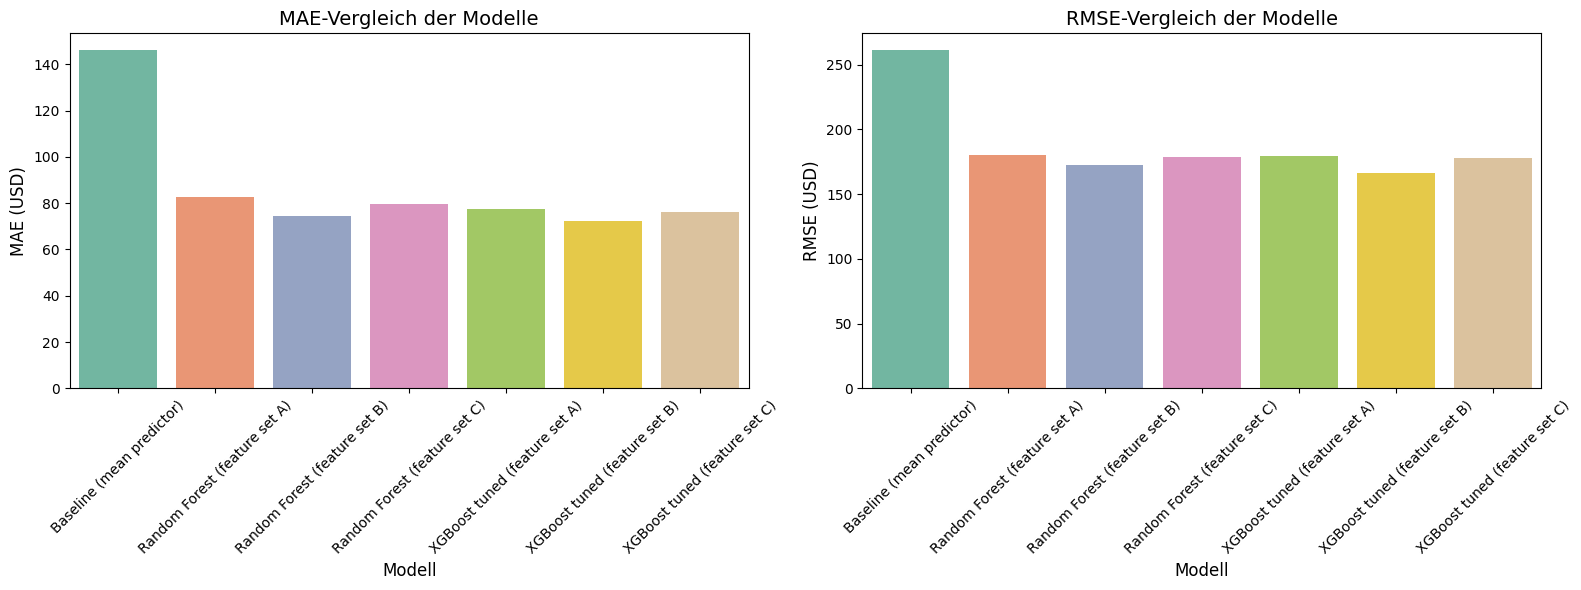

In [237]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    ax=ax[0],
    x="model",
    y="MAE",
    data=results_df_oos,
    hue="model",
    palette="Set2",
    legend=False
)
ax[0].set_title("MAE-Vergleich der Modelle", fontsize=14)
ax[0].set_xlabel("Modell", fontsize=12)
ax[0].set_ylabel("MAE (USD)", fontsize=12)
ax[0].tick_params(axis="x", rotation=45)

sns.barplot(
    ax=ax[1],
    x="model",
    y="RMSE",
    data=results_df_oos,
    hue="model",
    palette="Set2",
    legend=False
)
ax[1].set_title("RMSE-Vergleich der Modelle", fontsize=14)
ax[1].set_xlabel("Modell", fontsize=12)
ax[1].set_ylabel("RMSE (USD)", fontsize=12)
ax[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Actual vs. Predicted Scatter

Die tabellarische Gegenüberstellung von RMSE und MAE gibt zwar Aufschluss über 
die durchschnittliche Vorhersagegenauigkeit, verbirgt jedoch die zugrundeliegende 
Fehlerstruktur. 

Ein Scatter Plot der tatsächlichen gegen die vorhergesagten Preise 
ermöglicht eine differenziertere Beurteilung: Er zeigt, ob Fehler gleichmäßig 
über alle Preisklassen verteilt sind, oder ob das Modell systematisch bestimmte 
Preisbereiche über- bzw. unterschätzt.

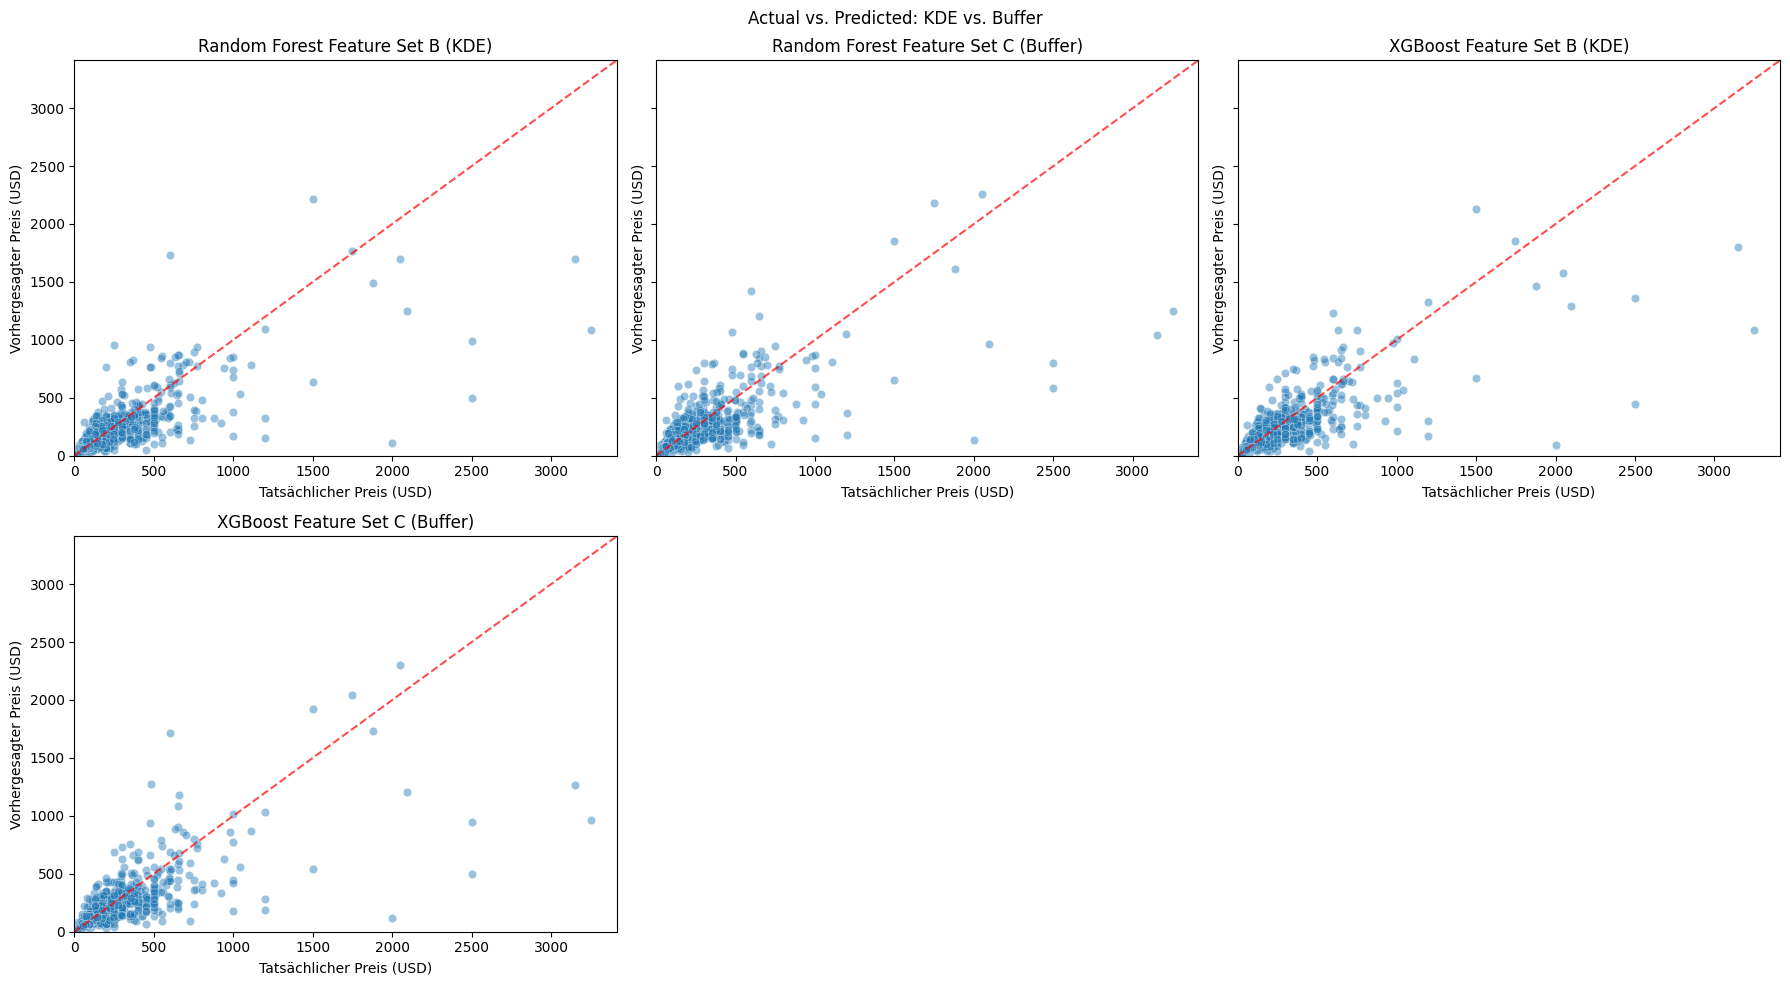

In [238]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

plot_data = [
    (y_pred_rf_B, "Random Forest Feature Set B (KDE)"),
    (y_pred_rf_C, "Random Forest Feature Set C (Buffer)"),
    (y_pred_xgb_tuned_B, "XGBoost Feature Set B (KDE)"),
    (y_pred_xgb_tuned_C, "XGBoost Feature Set C (Buffer)")
]

max_val = max(
    y_test.max(),
    y_pred_rf_B.max(),
    y_pred_rf_C.max(),
    y_pred_xgb_tuned_B.max(),
    y_pred_xgb_tuned_C.max()
) * 1.05

for ax, (pred, title) in zip(axes, plot_data):
    ax.scatter(
        y_test,
        pred,
        alpha=0.45,
        edgecolors="white",   # fix hier
        linewidths=0.4        # fix hier
    )
    ax.plot([0, max_val], [0, max_val], "r--", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Tatsächlicher Preis (USD)")
    ax.set_ylabel("Vorhergesagter Preis (USD)")
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)

# Leere Subplots ausblenden
for ax in axes[len(plot_data):]:
    ax.set_visible(False)

plt.suptitle("Actual vs. Predicted: KDE vs. Buffer")
plt.tight_layout()
plt.show()

Der Vergleich der Actual-vs.-Predicted-Plots zeigt, ob sich KDE- und Buffer-Features auch in der Fehlerstruktur unterscheiden. Besonders relevant ist, ob eines der beiden Feature Sets hochpreisige Listings besser abbilden kann oder ob beide Modelle ähnliche Schwächen im oberen Preissegment zeigen.

Wenn beide Modelle hochpreisige Listings systematisch unterschätzen, deutet dies darauf hin, dass die verbleibenden Fehler weniger an der Art der POI-Features liegen, sondern eher an nicht erfassten Preisfaktoren wie Ausstattung, Qualität, Bewertungen, Saison oder direkter Küstennähe.

Beide Modelle zeigen im unteren Preissegment eine gute Übereinstimmung 
mit der Ideallinie, wobei das XGBoost Modell etwas besser abschneidet. Zusätzlich folgen die Vorhersagen des XGBoost, im Vergleich zum Random Forest, der 
Diagonalen bis in höhere Preisbereiche etwas besser, was die leicht besseren 
Out-of-Sample Metriken erklärt. 

Dennoch 
zeigt sich dasselbe grundlegende Muster: Sehr hochpreisige Listings ab 2.000 USD 
werden systematisch unterschätzt, da die zugrundeliegenden Preistreiber nicht im Feature Set enthalten sind.

## Residuenanalyse

Ergänzend zum Scatter Plot analysieren wir die Residuenum zu prüfen, ob die 
Vorhersagefehler systematischer oder zufälliger Natur sind. Während der Scatter 
Plot die absolute Abweichung von der Ideallinie visualisiert, gibt die 
Residuenanalyse Aufschluss darüber, ob das Modell bestimmte Preisbereiche 
konsistent über- oder unterschätzt und ob die Fehler gleichmäßig über alle 
Preisklassen verteilt sind.

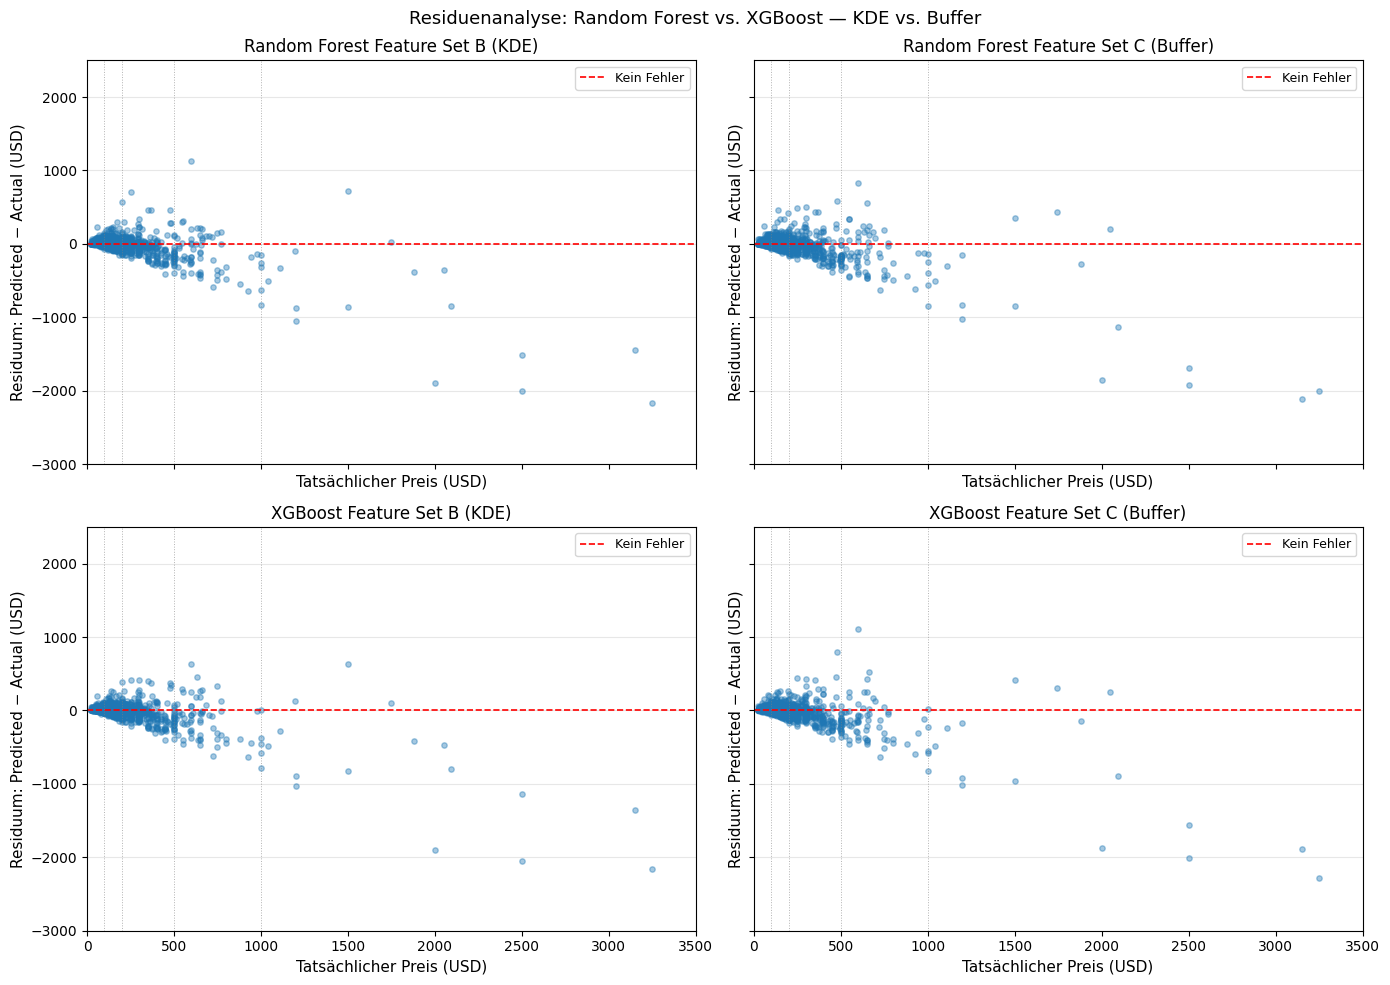

In [239]:
df_all = pd.DataFrame({
    "y_test": y_test,
    "rf_B":   y_pred_rf_B,
    "rf_C":   y_pred_rf_C,
    "xgb_B":  y_pred_xgb_tuned_B,
    "xgb_C":  y_pred_xgb_tuned_C,
})

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True, sharex=True)

models = [
    (axes[0, 0], "rf_B",  "Random Forest Feature Set B (KDE)"),
    (axes[0, 1], "rf_C",  "Random Forest Feature Set C (Buffer)"),
    (axes[1, 0], "xgb_B", "XGBoost Feature Set B (KDE)"),
    (axes[1, 1], "xgb_C", "XGBoost Feature Set C (Buffer)"),
]

for ax, col, title in models:
    residuals = df_all[col] - df_all["y_test"]

    ax.scatter(df_all["y_test"], residuals, alpha=0.4, s=15)
    ax.axhline(0, color="red", linewidth=1.2, linestyle="--", label="Kein Fehler")

    for xline in [100, 200, 500, 1000]:
        ax.axvline(xline, color="gray", linewidth=0.7, linestyle=":", alpha=0.6)

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Tatsächlicher Preis (USD)", fontsize=11)
    ax.set_ylabel("Residuum: Predicted − Actual (USD)", fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 3500)
    ax.set_ylim(-3000, 2500)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

plt.suptitle("Residuenanalyse: Random Forest vs. XGBoost — KDE vs. Buffer", fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/s_/tc52sgkj18d_pnr8h48bmz3m0000gn/T/ipykernel_7276/2479634176.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


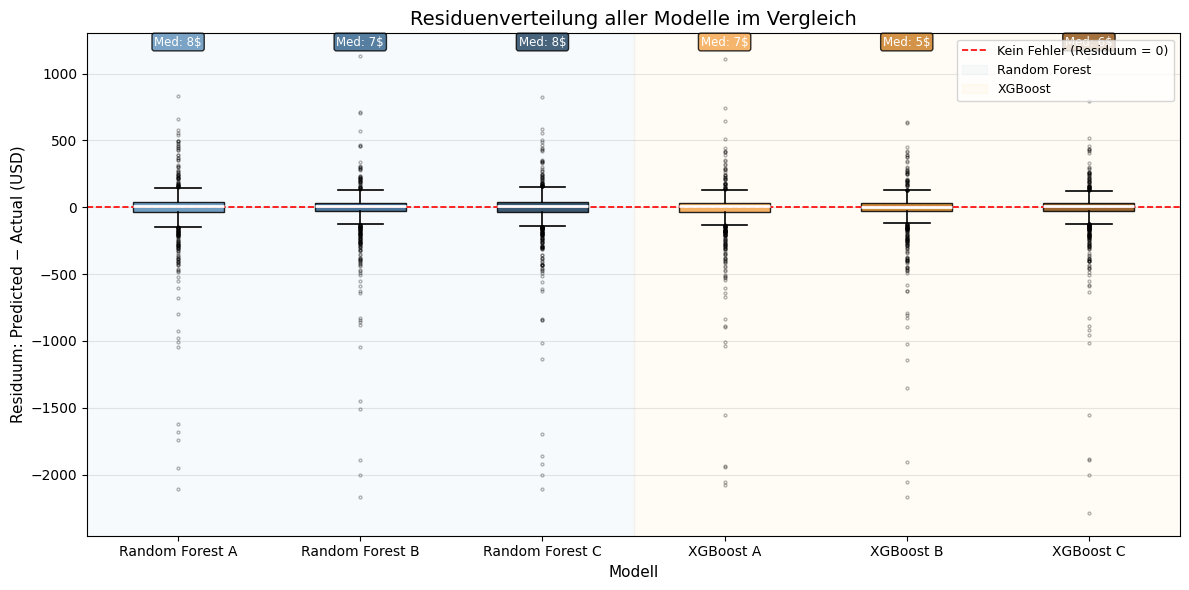

In [240]:
# Residuen für alle 6 Modelle berechnen
residuals_df = pd.DataFrame({
    "Random Forest A":  y_pred_rf_A  - y_test.values,
    "Random Forest B":  y_pred_rf_B  - y_test.values,
    "Random Forest C":  y_pred_rf_C  - y_test.values,
    "XGBoost A":        y_pred_xgb_tuned_A - y_test.values,
    "XGBoost B":        y_pred_xgb_tuned_B - y_test.values,
    "XGBoost C":        y_pred_xgb_tuned_C - y_test.values,
})

fig, ax = plt.subplots(figsize=(12, 6))

colors = ["#5B8DB8", "#2E5F8A", "#1B3E5C", "#F4A44A", "#C97A1E", "#8C4F0F"]

bp = ax.boxplot(
    [residuals_df[col] for col in residuals_df.columns],
    labels=residuals_df.columns,
    patch_artist=True,
    notch=False,
    showfliers=True,
    flierprops=dict(marker="o", markersize=2, alpha=0.3, linestyle="none"),
    medianprops=dict(color="white", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.axhline(0, color="red", linewidth=1.2, linestyle="--", label="Kein Fehler (Residuum = 0)")

# Hintergrund-Shading für Modellgruppen
ax.axvspan(0.5, 3.5, alpha=0.04, color="steelblue", label="Random Forest")
ax.axvspan(3.5, 6.5, alpha=0.04, color="orange", label="XGBoost")

ax.set_title("Residuenverteilung aller Modelle im Vergleich", fontsize=14)
ax.set_ylabel("Residuum: Predicted − Actual (USD)", fontsize=11)
ax.set_xlabel("Modell", fontsize=11)
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Median-Werte als Text über den Boxen anzeigen
for i, col in enumerate(residuals_df.columns, start=1):
    median_val = residuals_df[col].median()
    ax.text(i, ax.get_ylim()[1] * 0.93, f"Med: {median_val:.0f}$",
            ha="center", fontsize=8.5, color="white",
            bbox=dict(boxstyle="round,pad=0.2", facecolor=colors[i-1], alpha=0.8))

plt.tight_layout()
plt.show()

Die Residuenanalyse wird in zwei Plots dargestellt: Der Scatter Plot zeigt die
Fehlerstruktur entlang der Preisskala, der Boxplot vergleicht die
Residuenverteilungen aller vier Modelle auf einen Blick.

**Scatter Plot (Residuen nach Preissegment):**

Beide Modelle zeigen ein sehr ähnliches Residuenmuster. Im unteren Preissegment
(0–500 USD) konzentrieren sich die Residuen eng um die Nulllinie. Die Vorhersagen
sind hier präzise und weitgehend unverzerrt. Dies ist auf die Verteilung der 
Trainingsdaten zurückzuführen, in der niedrigpreisige Listings deutlich stärker 
vertreten sind.

Ab ca. 1.000 USD ist eine deutliche Verschiebung der Residuen in den negativen
Bereich erkennbar, die sich mit steigendem Preis verstärkt. Dies deutet auf eine
systematische Unterschätzung hochpreisiger Listings hin. 

Gleichzeitig nimmt die
Streuung der Fehler mit steigendem Preis zu. Diese trichterförmige Struktur ist
ein klassisches Zeichen von Heteroskedastizität. Die Prognoseunsicherheit ist
nicht gleichmäßig verteilt, sondern wächst mit dem Preisniveau.

Da beide Modelle dieses Muster gleichermaßen zeigen, sind die beobachteten
Schwächen nicht primär modellbedingt, sondern auf die unzureichende
Feature-Repräsentation preisbestimmender Faktoren im oberen Segment
zurückzuführen.

**Boxplot (Residuenverteilung aller Modelle im Vergleich):**

Der Vergleichsboxplot ergänzt den Scatter Plot um eine modellübergreifende
Perspektive. Alle vier Modelle zeigen eine asymmetrische Residuenverteilung:

Der Median liegt in allen Fällen knapp über null (RF-A: 8 USD, RF-B: 7 USD, RF-C: 8 USD
XGB-A: 7 USD, XGB-B: 5 USD, XGB-C: 6), was auf eine leichte systematische Überschätzung im mittleren
Preissegment hindeutet. Die Whisker und Ausreißer erstrecken sich jedoch weit
in den negativen Bereich. Ein weiterer Beleg für die strukturelle
Unterschätzung im oberen Preissegment.

Erkennbar ist zudem, dass Feature Set B die Streuung der Residuen bei beiden
Algorithmen leicht reduziert: Die Boxen von Random Forest B und XGBoost B sind
etwas schmaler als im Feature Set A. Dies bestätigt den messbaren
Mehrwert der KDE-Features nicht nur in den aggregierten Metriken (RMSE, MAE),
sondern auch in der Fehlerverteilung selbst.

## Feature Importance

Die Feature-Importance-Analyse dient dazu, die Modellentscheidungen inhaltlich besser zu verstehen. Besonders relevant ist hier, ob die räumlichen Features aus Part 2 tatsächlich vom Modell genutzt werden.

Da in dieser Analyse KDE- und Buffer-Features miteinander verglichen werden, werden die Feature Importances für die Modelle mit Feature Set B und Feature Set C gegenübergestellt. Dadurch lässt sich prüfen, ob die kontinuierlichen KDE-Scores oder die direkten Buffer-Zählungen stärker zur Preisvorhersage beitragen.

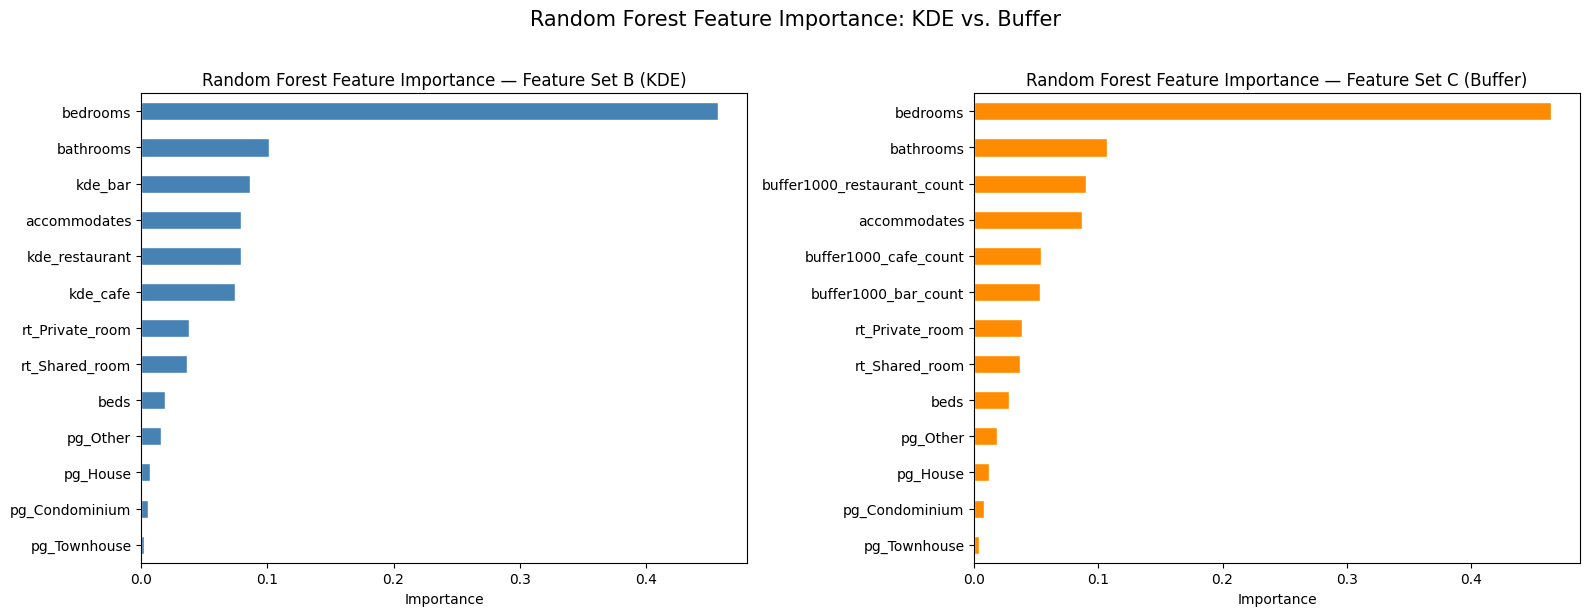

In [241]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Feature Importance: KDE
rf_importance_B = pd.Series(
    rf_model_B.feature_importances_,
    index=X_B_train.columns
).sort_values(ascending=True)

rf_importance_B.plot(
    kind="barh",
    ax=axes[0],
    color="steelblue",
    edgecolor="white"
)
axes[0].set_title("Random Forest Feature Importance — Feature Set B (KDE)")
axes[0].set_xlabel("Importance")

# Random Forest Feature Importance: Buffer
rf_importance_C = pd.Series(
    rf_model_C.feature_importances_,
    index=X_C_train.columns
).sort_values(ascending=True)

rf_importance_C.plot(
    kind="barh",
    ax=axes[1],
    color="darkorange",
    edgecolor="white"
)
axes[1].set_title("Random Forest Feature Importance — Feature Set C (Buffer)")
axes[1].set_xlabel("Importance")

plt.suptitle("Random Forest Feature Importance: KDE vs. Buffer", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

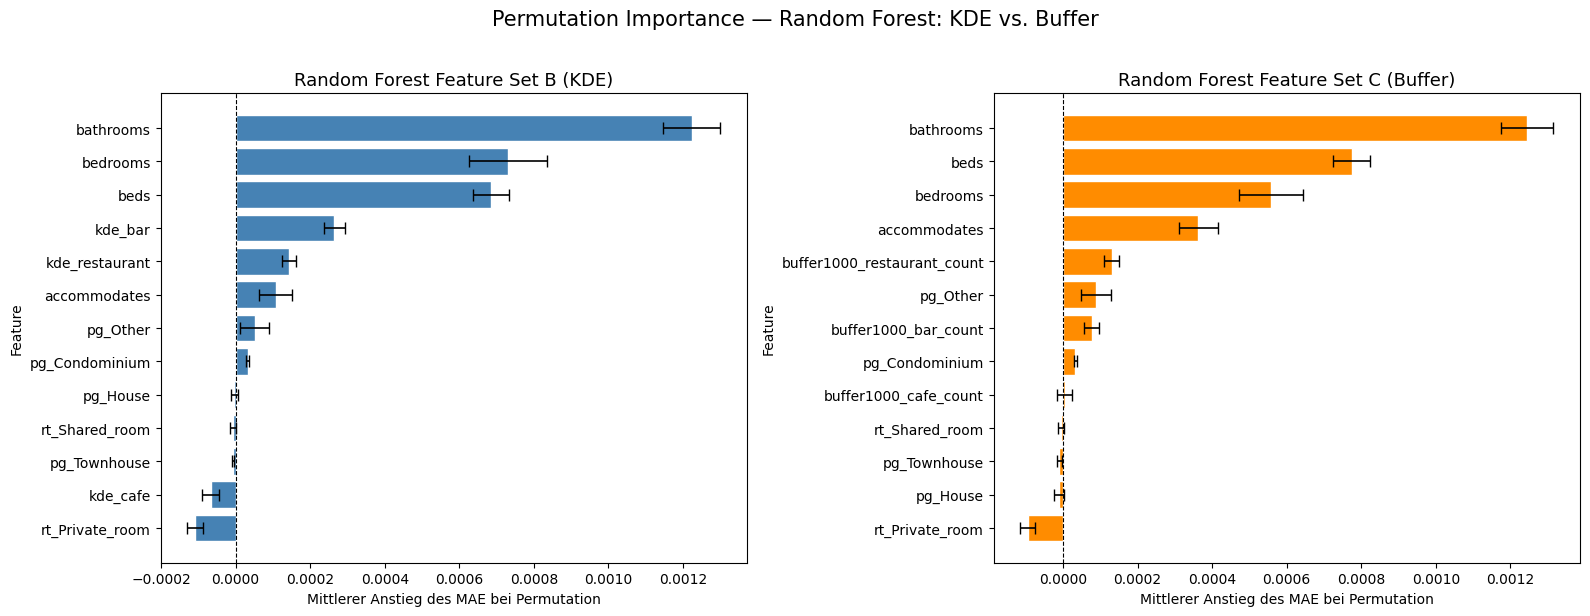

In [242]:
# Permutation Importance berechnen
perm_rf_B = permutation_importance(
    rf_model_B, X_B_test, y_test, n_repeats=10, random_state=67,
)
perm_rf_C = permutation_importance(
    rf_model_C, X_C_test, y_test, n_repeats=10, random_state=67,
)

# In DataFrames umwandeln und sortieren
perm_df_rf_B = pd.DataFrame({
    "feature":    X_B_test.columns,
    "importance": perm_rf_B.importances_mean,
    "std":        perm_rf_B.importances_std
}).sort_values("importance", ascending=True)

perm_df_rf_C = pd.DataFrame({
    "feature":    X_C_test.columns,
    "importance": perm_rf_C.importances_mean,
    "std":        perm_rf_C.importances_std
}).sort_values("importance", ascending=True)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, perm_df, title, color in zip(
    axes,
    [perm_df_rf_B, perm_df_rf_C],
    ["Random Forest Feature Set B (KDE)", "Random Forest Feature Set C (Buffer)"],
    ["steelblue", "darkorange"]
):
    ax.barh(
        perm_df["feature"],
        perm_df["importance"],
        xerr=perm_df["std"],
        color=color,
        edgecolor="white",
        capsize=4,
        error_kw={"elinewidth": 1.2, "ecolor": "black"}
    )
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Mittlerer Anstieg des MAE bei Permutation")
    ax.set_ylabel("Feature")

plt.suptitle("Permutation Importance — Random Forest: KDE vs. Buffer", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

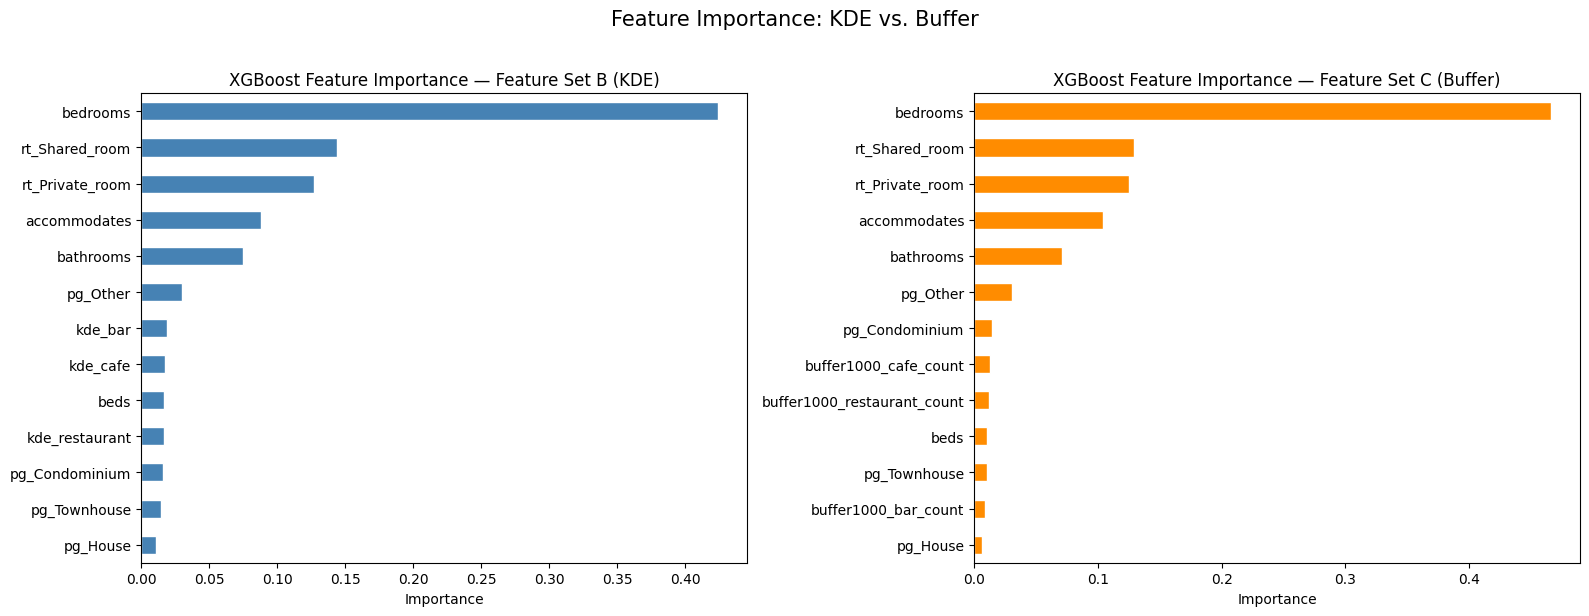

In [243]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost Feature Importance: KDE
xgb_importance_B = pd.Series(
    xgb_tuned_B.feature_importances_,
    index=X_B_train.columns
).sort_values(ascending=True)

xgb_importance_B.plot(
    kind="barh",
    ax=axes[0],
    color="steelblue",
    edgecolor="white"
)
axes[0].set_title("XGBoost Feature Importance — Feature Set B (KDE)")
axes[0].set_xlabel("Importance")

# XGBoost Feature Importance: Buffer
xgb_importance_C = pd.Series(
    xgb_tuned_C.feature_importances_,
    index=X_C_train.columns
).sort_values(ascending=True)

xgb_importance_C.plot(
    kind="barh",
    ax=axes[1],
    color="darkorange",
    edgecolor="white"
)
axes[1].set_title("XGBoost Feature Importance — Feature Set C (Buffer)")
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance: KDE vs. Buffer", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

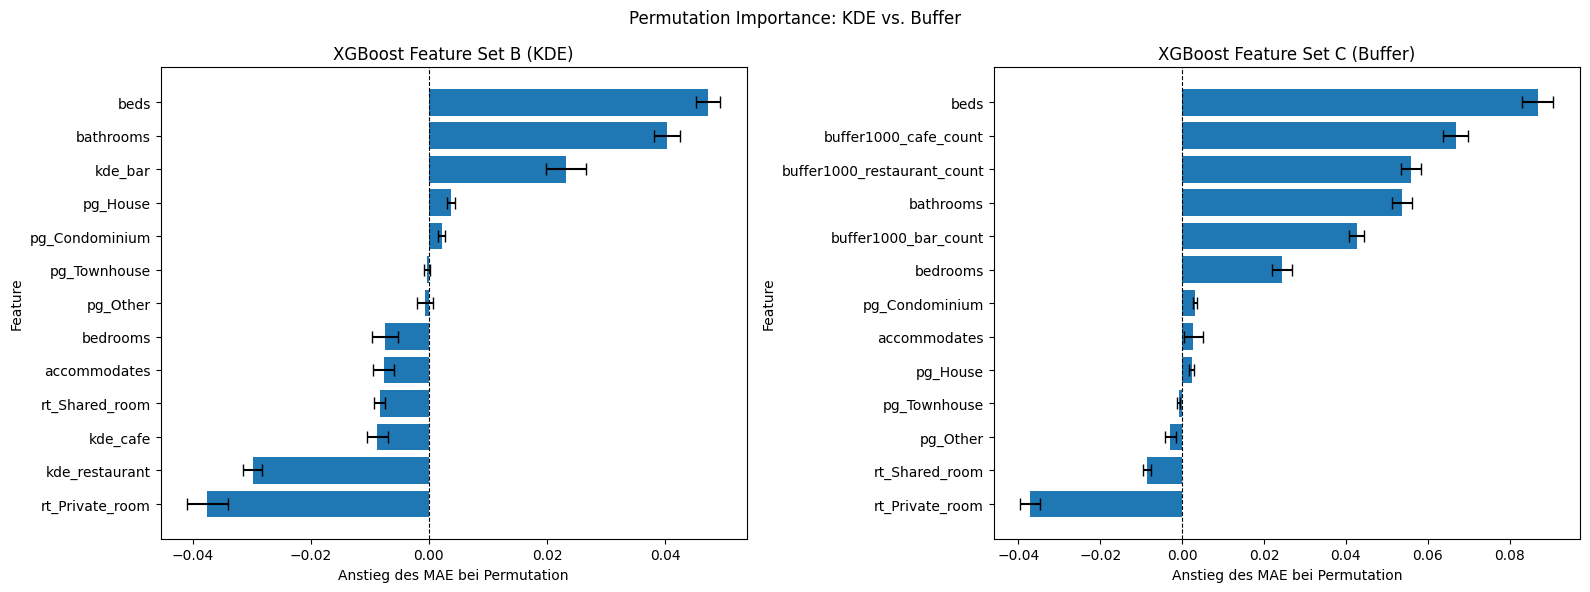

In [244]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_for_perm = [
    (xgb_tuned_B, X_B_test, "XGBoost Feature Set B (KDE)"),
    (xgb_tuned_C, X_C_test, "XGBoost Feature Set C (Buffer)")
]

for ax, (model, X_test_current, title) in zip(axes, models_for_perm):
    perm = permutation_importance(
        model,
        X_test_current,
        y_test,
        n_repeats=10,
        random_state=67,
        scoring="neg_mean_absolute_error"
    )

    perm_df = pd.DataFrame({
        "feature": X_test_current.columns,
        "importance": perm.importances_mean,
        "std": perm.importances_std
    }).sort_values("importance", ascending=True)

    ax.barh(
        perm_df["feature"],
        perm_df["importance"],
        xerr=perm_df["std"],
        capsize=4
    )

    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Anstieg des MAE bei Permutation")
    ax.set_ylabel("Feature")

plt.suptitle("Permutation Importance: KDE vs. Buffer")
plt.tight_layout()
plt.show()

Die Feature-Importance-Analyse gibt Aufschluss darüber, welche Merkmale die 
Modelle tatsächlich zur Preisvorhersage nutzen und wie zuverlässig dieser 
Beitrag auf ungesehenen Daten ist.

Über alle Modelle und Methoden hinweg erweisen sich `bedrooms`, `bathrooms`, 
`accommodates` und `beds` als die stärksten Prädiktoren. Dies ist inhaltlich 
nachvollziehbar: Diese Variablen beschreiben Kapazität und Nutzungsform einer 
Unterkunft direkt und sind damit die offensichtlichsten Preistreiber auf dem 
Airbnb-Markt.

Die modell-interne (Gini-basierte) Importance und die Permutation Importance 
liefern teils unterschiedliche Rangfolgen, die sich gegenseitig ergänzen. 
Während die Gini-Importance zeigt, welche Features bei der Baumkonstruktion 
am häufigsten verwendet werden, misst die Permutation Importance den tatsächlichen 
Einfluss auf den Testfehler und liefert damit das robustere Bild. 
So rücken bei der Permutation Importance `bathrooms` (Random Forest) und `beds` 
(XGBoost) noch stärker in den Vordergrund, was darauf hindeutet, dass ihr 
Beitrag durch die Gini-Methode teilweise unterschätzt wird.

Die KDE-Features (`kde_bar`, `kde_restaurant`) erzielen in der Permutation 
Importance stabile, positive Werte mit engen Fehlerbalken. Das bedeutet: 
Die gastronomische Umgebungsdichte ist ein eigenständiges, robustes Signal
und nicht nur ein indirekter Proxy für die Unterkunftsgröße. Listings in 
gastronomisch gut erschlossenen Stadtteilen erzielen systematisch höhere Preise, 
unabhängig davon, wie groß die Unterkunft ist.

Einzelne Features wie `rt_Private_room` oder `kde_cafe` weisen leicht negative 
Permutation-Importance-Werte auf. Das bedeutet nicht, dass sie schädlich sind, 
sondern dass ihre Information bereits durch andere Variablen abgedeckt wird, beispielsweise durch `accommodates` im Fall des Zimmertyps. Das Modell kann auf diese 
Features verzichten, ohne Vorhersagequalität zu verlieren.

# Summary: Main Takeaways

Diese Case Study hat untersucht, ob und wie gut die Nachtpreise von 
Airbnb-Listings in San Diego durch strukturelle Unterkunftsmerkmale 
und räumliche Informationen vorhergesagt werden können. 
Die Analyse lässt sich in vier zentrale Erkenntnisse zusammenfassen.


## 1. Die Preisverteilung erfordert methodische Sorgfalt

Die Zielvariable `price` ist stark rechtsschief verteilt: 
Der Mittelwert (≈ 217 USD) liegt deutlich über dem Median, und 
einzelne Listings erzielen Preise jenseits von 2.000 USD pro Nacht. 
Eine Log-Transformation war daher notwendig, um die Varianz zu 
stabilisieren und den Einfluss extremer Ausreißer auf die 
Modelltraining-Phase zu reduzieren. Gleichzeitig macht genau diese 
Heterogenität die Preisvorhersage anspruchsvoll: Hochpreisige Listings 
folgen einer anderen Logik als Standardunterkünfte und sind im 
Datensatz zu selten vertreten, als dass die Modelle sie zuverlässig 
lernen könnten.


## 2. Unterkunftsgröße ist der stärkste Preistreiber

Über alle Modelle und Feature Sets hinweg erweist sich `bedrooms` 
als wichtigstes Feature. Die Anzahl der Schlafzimmer, gefolgt von 
`accommodates`, `bathrooms` und `beds`, korreliert stark positiv 
mit dem Preis. Dies ist inhaltlich plausibel. Größere Unterkünfte 
bieten mehr Kapazität, mehr Wohnfläche und sprechen in der Regel 
größere Reisegruppen an, die bereit sind, mehr zu zahlen. 
Auch der Zimmertyp spielt eine wichtige Rolle. Ganze Unterkünfte 
(`Entire home/apt`) erzielen systematisch höhere Preise als private 
oder geteilte Zimmer.


## 3. Räumliche POI-Dichte liefert messbaren Mehrwert

Die zentrale methodische Innovation dieser Analyse war die Berechnung 
von Kernel Density Estimation (KDE) Scores für drei gastronomische 
POI-Kategorien (Restaurants, Cafés, Bars) aus OpenStreetMap-Daten. 
Die Integration dieser räumlichen Features in Feature Set B führte 
bei **beiden Modellen** zu einer konsistenten Verbesserung der 
Vorhersagegenauigkeit:

| Modell | RMSE (Set A) | RMSE (Set B) | Verbesserung |
|---|---|---|---|
| Random Forest | 180,63 USD | 172,78 USD | − 7,85 USD |
| XGBoost | 179,62 USD | 166,01 USD | − 13,61 USD |

Dies bestätigt die eingangs aufgestellte Hypothese: 

Die Lage einer Unterkunft relativ zur gastronomischen Infrastruktur 
des Stadtgebiets ist ein preisrelevantes Signal. Airbnb-Gäste sind 
bereit, für die Nähe zu Restaurants, Cafés und Bars einen Aufpreis 
zu zahlen oder Hosts in solchen Lagen verlangen von vornherein 
höhere Preise. Besonders beim Random Forest nehmen die KDE-Features 
eine prominente Rolle in der Feature Importance ein, 
was ihren inhaltlichen Erklärungsbeitrag unterstreicht.


## 4. Beide Modelle generalisieren gut, stoßen aber im oberen Preissegment an ihre Grenzen

XGBoost mit Feature Set B erzielt die beste Gesamtperformance und zeigt im Vergleich zum 
Random Forest eine robustere Generalisierung. Die Lücke zwischen 
In-Sample- und Out-of-Sample-Fehler ist beim XGBoost kleiner, 
was auf geringeres Overfitting hindeutet. 

Die Residuenanalyse offenbart jedoch ein für beide Modelle 
gemeinsames, strukturelles Problem. Im unteren Preissegment 
(0–500 USD) sind die Vorhersagen präzise und unverzerrt. 
Ab ≈ 1.000 USD werden Listings systematisch unterschätzt, 
und die Fehlervarianz wächst mit dem Preisniveau. 

Diese Schwäche ist nicht modellbedingt, sondern auf die 
fehlende Feature-Repräsentation preisbestimmender Faktoren
im oberen Segment zurückzuführen. Merkmale wie Ausstattungsqualität, 
Bewertungen, Strandnähe, Inneneinrichtung oder saisonale Nachfrage 
sind im vorliegenden Datensatz nicht enthalten, dürften aber 
maßgeblich dazu beitragen, warum manche Listings das Vier- bis 
Zehnfache des Durchschnittspreises erzielen.


## Fazit

Der vorliegende Datensatz erlaubt eine solide Preisvorhersage 
im mittleren Preissegment. Die Integration räumlicher KDE-Features 
aus OpenStreetMap verbessert die Modellgüte messbar und zeigt, 
dass urbane Kontextinformation einen echten Mehrwert gegenüber 
rein listing-basierten Merkmalen bietet. Für eine noch präzisere 
Preisschätzung wären zusätzliche 
Datenquellen wie Bewertungsdaten, Ausstattungsdetails oder 
Distanz-Features zu Stränden und touristischen Attraktionen 
vielversprechende nächste Schritte.